# NB-04 · Temporal Regression Model
### Bubble Flow Analysis System — Stage 4

**Roadmap reference:** Stage 4 — Temporal Regression (Section 2, NB-04 in Section 7)  
**Gate in:** `tracks.parquet` (NB-03) + `config.json` (NB-00) + documented NB-03 gate record  
**Gate out:** `tracks_temporal.parquet` (Appendix A.4)  
**Acceptance gate:** Velocity MAE < 10 % of reference value; diameter RMSE < 0.5 mm  

---
### Two execution modes

| Mode | When | How |
|---|---|---|
| **`'classical'`** | No checkpoint / insufficient tracks *(current state)* | Savitzky-Golay smoothed finite differences |
| **`'neural'`** | ≥ 20 long tracks available + checkpoint exists | 1D-CNN + BiLSTM trained on track sequences |

Both modes produce an **identical `tracks_temporal.parquet` schema** — NB-05 does not know or care which mode was used.

---
### Parameters locked from pre-build analysis

| Property | Value | Source |
|---|---|---|
| SG window length | **9** frames | Gives MAE 0.5 % on synthetic test; best balance of smoothing vs resolution |
| SG poly order | 2 | Captures mild bubble acceleration |
| Sequence length (neural) | 16 frames | 0.358 s, ~16 % of median track lifetime |
| Feature vector | 7 per timestep | pos_x, pos_y, area, diameter, aspect_ratio, orientation, confidence |
| LSTM hidden dim | 64 | ~73 k parameters total — lightweight (roadmap §4) |
| Velocity range | 164 mm/s (p50) – 544 mm/s (p95) | Measured from NB-03 displacement data |
| Min track length (classical) | 3 frames | Can compute 2 finite differences |

In [56]:
import sys, subprocess
try:
    from google.colab import drive; IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    from google.colab import drive
    try:
        drive.mount('/content/drive', force_remount=False)
        print('Drive mounted at /content/drive')
    except Exception as _e:
        if 'already contain files' in str(_e) or 'symlink' in str(_e):
            subprocess.run(['umount', '/content/drive'], capture_output=True)
            subprocess.run(['rm', '-rf', '/content/drive'], capture_output=True)
            drive.mount('/content/drive', force_remount=False)
            print('Drive remounted successfully.')
        else:
            raise
else:
    print('Not in Colab - Drive mount skipped.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted at /content/drive


## Cell 0B - Dependency Check

In [40]:
import sys, subprocess, importlib.util
REQUIRED = [('pyarrow','pyarrow'),('scipy','scipy'),('tqdm','tqdm')]
missing = [pkg for pkg,mod in REQUIRED if importlib.util.find_spec(mod) is None]
if missing:
    r = subprocess.run([sys.executable,'-m','pip','install','--quiet']+missing,
                       capture_output=True, text=True)
    if r.returncode != 0: raise RuntimeError('Dependency install failed:\n'+r.stderr)
    print('Installed:', missing)
else:
    print('All dependencies present.')


All dependencies present.


## Cell 0C - Path Configuration

In [41]:
from pathlib import Path
DRIVE_PROJECT_PATH = 'SIGNAL_NN_2026/HIDRO_2026'
if IN_COLAB:
    DRIVE_ROOT = Path('/content/drive/MyDrive') / DRIVE_PROJECT_PATH
else:
    DRIVE_ROOT = Path.home() / 'BubbleFlow'
print('DRIVE_ROOT   :', DRIVE_ROOT)
print('Drive exists :', DRIVE_ROOT.exists())


DRIVE_ROOT   : /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026
Drive exists : True


# NB-04 · Temporal Regression Model
### Bubble Flow Analysis System — Stage 4

**Roadmap reference:** Stage 4 — Temporal Regression (Section 2, NB-04 in Section 7)  
**Gate in:** `tracks.parquet` (NB-03) + `config.json` (NB-00) + documented NB-03 gate record  
**Gate out:** `tracks_temporal.parquet` (Appendix A.4)  
**Acceptance gate:** Velocity MAE < 10 % of reference value; diameter RMSE < 0.5 mm  

---
### Two execution modes

| Mode | When | How |
|---|---|---|
| **`'classical'`** | No checkpoint / insufficient tracks *(current state)* | Savitzky-Golay smoothed finite differences |
| **`'neural'`** | ≥ 20 long tracks available + checkpoint exists | 1D-CNN + BiLSTM trained on track sequences |

Both modes produce an **identical `tracks_temporal.parquet` schema** — NB-05 does not know or care which mode was used.

---
### Parameters locked from pre-build analysis

| Property | Value | Source |
|---|---|---|
| SG window length | **9** frames | Gives MAE 0.5 % on synthetic test; best balance of smoothing vs resolution |
| SG poly order | 2 | Captures mild bubble acceleration |
| Sequence length (neural) | 16 frames | 0.358 s, ~16 % of median track lifetime |
| Feature vector | 7 per timestep | pos_x, pos_y, area, diameter, aspect_ratio, orientation, confidence |
| LSTM hidden dim | 64 | ~73 k parameters total — lightweight (roadmap §4) |
| Velocity range | 164 mm/s (p50) – 544 mm/s (p95) | Measured from NB-03 displacement data |
| Min track length (classical) | 3 frames | Can compute 2 finite differences |

---
## Imports

In [42]:
from pathlib import Path
import sys
import json
import math
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.signal import savgol_filter
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False
    savgol_filter = None
    warnings.warn('scipy.signal.savgol_filter not available. Rolling fallback will be used.')


def safe_mkdir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def safe_savefig(path, dpi=140, bbox_inches='tight', fallback_dir='/content/nb04_outputs'):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    try:
        plt.savefig(path, dpi=dpi, bbox_inches=bbox_inches)
        print(f'[OK] Figure saved at: {path}')
        return path
    except Exception as e:
        print(f'[WARNING] Could not save figure at: {path}')
        print(f'[WARNING] Reason: {type(e).__name__}: {e}')
        fallback_dir = Path(fallback_dir)
        fallback_dir.mkdir(parents=True, exist_ok=True)
        fallback_path = fallback_dir / path.name
        plt.savefig(fallback_path, dpi=dpi, bbox_inches=bbox_inches)
        print(f'[OK] Figure saved at fallback path: {fallback_path}')
        return fallback_path


def read_json_if_exists(path, default=None):
    path = Path(path)
    if not path.exists() or not path.is_file():
        return default
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def write_json(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    print(f'[OK] JSON saved: {path}')

import math
from tqdm.auto import tqdm
print('NB-04  Temporal Model  imports OK')

NB-04  Temporal Model  imports OK


---
## Cell 1 - Configuration
Edit only this cell.

In [43]:
# PATHS
CONFIG_PATH       = str(DRIVE_ROOT / 'campaigns/setup_A/config.json')
TRACKS_PATH       = str(DRIVE_ROOT / 'campaigns/setup_A/outputs/tracking/tracks.parquet')
GATE_PATH         = str(DRIVE_ROOT / 'campaigns/setup_A/outputs/tracking/tracking_gate.json')
CHECKPOINT_PATH   = ''    # set to .pt when neural mode is ready
OUTPUT_DIR        = str(DRIVE_ROOT / 'campaigns/setup_A/outputs/temporal')
RUN_LABEL         = 'run_001_Q10'
SETUP_ID          = 'setup_A'
GROUND_TRUTH_PATH = ''    # CSV [frame_id, global_bubble_id, vv_gt, vh_gt]

# MODE
TEMPORAL_MODE     = 'auto'   # 'auto' | 'classical' | 'neural'
SMOOTHER          = 'savitzky_golay'   # or 'rolling_median'

# CLASSICAL
SG_WINDOW_LENGTH  = 9
SG_POLYORDER      = 2
MIN_TRACK_LEN_CL  = 3
MIN_TRACK_LEN_FRAMES = 3

# NEURAL
MIN_TRACK_LEN_NN  = 16
MIN_TRACKS_TRAIN  = 20
SEQ_LEN           = 16
N_FEATURES        = 7
CNN_CHANNELS      = [32, 64]
LSTM_HIDDEN       = 64
LSTM_LAYERS       = 2
DROPOUT           = 0.2
VAL_SPLIT         = 0.20
BATCH_SIZE        = 32
MAX_EPOCHS        = 50
PATIENCE          = 10
LEARNING_RATE     = 1e-3
LOSS_W_VEL        = 0.6
LOSS_W_EVENT      = 0.3
LOSS_W_CONSIST    = 0.1
EVENT_MAP         = {'stable':0,'merge':1,'split':2,'lost':3}
EVENT_MAP_INV     = {v:k for k,v in EVENT_MAP.items()}

# FALLBACKS
FALLBACK_MPP  = 0.23148148
FALLBACK_FPS  = 44.638
SCALE_INV     = 2.0

# OUTPUT PATHS
OUT = safe_mkdir(OUTPUT_DIR)
TRACKS_TEMPORAL_PATH    = OUT / 'tracks_temporal.parquet'
TEMPORAL_GATE_PATH      = OUT / 'temporal_gate.json'
TEMPORAL_DASHBOARD_PATH = OUT / 'temporal_dashboard.png'
print('Output dir:', OUT.resolve())


Output dir: /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026/campaigns/setup_A/outputs/temporal


---
## Cell 2 - Load config.json and Tracks

In [44]:
def load_config(path='config.json'):
    MANDATORY = ['mm_per_pixel','fps','roi_coords',
             'column_diameter_mm','reference_lines_px',
             'schema_version','created_at']
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f'config.json not found: {p.resolve()}')
    with open(p, encoding='utf-8') as f: cfg = json.load(f)
    missing = [k for k in MANDATORY if k not in cfg]
    if missing: raise KeyError(f'config.json missing fields: {missing}')
    return cfg

def read_json_if_exists(path, default=None):
    p = Path(path)
    if not p.exists(): return default if default is not None else {}
    with open(p, encoding='utf-8') as f: return json.load(f)

def write_json(path, obj):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    print(f'[OK] JSON saved: {path}')

try:
    phys_cfg       = load_config(CONFIG_PATH)
    MM_PER_PIXEL   = float(phys_cfg['mm_per_pixel'])
    MM_PER_PIXEL_UNC = float(phys_cfg.get('mm_per_pixel_uncertainty', 0.0))
    FPS            = float(phys_cfg['fps'])
    print(f"config.json loaded  mm_per_pixel={MM_PER_PIXEL:.6f}  fps={FPS:.4f}")
except FileNotFoundError as _e:
    print('[WARNING]', _e)
    phys_cfg = {}; MM_PER_PIXEL = FALLBACK_MPP; MM_PER_PIXEL_UNC = 0.0; FPS = FALLBACK_FPS

DT = 1.0 / FPS
tracking_gate      = read_json_if_exists(GATE_PATH)
tracking_gate_pass = bool(
    tracking_gate.get('gate_pass', False) or tracking_gate.get('exploratory_ok', True)
)
print(f'NB-03 gate_pass={tracking_gate.get("gate_pass")}  exploratory_ok={tracking_gate.get("exploratory_ok")}')

_tp = Path(TRACKS_PATH)
if not _tp.exists():
    raise FileNotFoundError(f'tracks.parquet not found: {_tp}\nRun NB-03 first.')
tracks = pd.read_parquet(_tp)
for col in ['centroid_mm','centroid_px','ellipse_axes_mm','centroid_full_px']:
    if col in tracks.columns and tracks[col].dtype == object:
        tracks[col] = tracks[col].apply(lambda v: json.loads(v) if isinstance(v, str) else v)
tracks = tracks.sort_values(['global_bubble_id','frame_id']).reset_index(drop=True)
print(f'Tracks loaded: {tracks.shape}  '
      f'{tracks["global_bubble_id"].nunique()} tracks  '
      f'{tracks["frame_id"].nunique()} frames')


config.json loaded  mm_per_pixel=0.231481  fps=44.6380
NB-03 gate_pass=False  exploratory_ok=True
Tracks loaded: (3595, 21)  105 tracks  378 frames


---
## Cell 3 - Normalise Tracks

In [45]:
def choose_col(df, candidates, required=True, label='column'):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f'Missing {label}. Expected one of {candidates}. Available columns: {list(df.columns)}')
    return None


def normalize_tracks(df, fps, mm_per_pixel):
    df = df.copy()

    id_col = choose_col(df, ['global_bubble_id', 'track_id', 'bubble_id', 'id'], label='track identity column')
    frame_col = choose_col(df, ['frame_id', 'frame_idx', 'frame', 'source_frame'], label='frame column')

    # Prefer full-frame coordinates for physical derivatives if available; otherwise use local coordinates.
    x_col = choose_col(df, ['x_full_mm', 'x_mm'], required=False, label='x mm column')
    y_col = choose_col(df, ['y_full_mm', 'y_mm'], required=False, label='y mm column')

    if x_col is None or y_col is None:
        px_x_col = choose_col(df, ['cx_full', 'x_full', 'cx'], label='x pixel column')
        px_y_col = choose_col(df, ['cy_full', 'y_full', 'cy'], label='y pixel column')
        if not np.isfinite(mm_per_pixel):
            raise ValueError('Cannot compute mm coordinates because mm_per_pixel is missing or invalid.')
        df['x_temporal_mm'] = pd.to_numeric(df[px_x_col], errors='coerce') * mm_per_pixel
        df['y_temporal_mm'] = pd.to_numeric(df[px_y_col], errors='coerce') * mm_per_pixel
    else:
        df['x_temporal_mm'] = pd.to_numeric(df[x_col], errors='coerce')
        df['y_temporal_mm'] = pd.to_numeric(df[y_col], errors='coerce')

    df['global_bubble_id'] = pd.to_numeric(df[id_col], errors='coerce').astype('Int64')
    df['frame_id'] = pd.to_numeric(df[frame_col], errors='coerce').astype('Int64')

    if 'time_s' in df.columns:
        df['time_s'] = pd.to_numeric(df['time_s'], errors='coerce')
    else:
        frame0 = df['frame_id'].min()
        df['time_s'] = (df['frame_id'].astype(float) - float(frame0)) / fps

    df['diameter_mm'] = pd.to_numeric(df['diameter_mm'], errors='coerce') if 'diameter_mm' in df.columns else np.nan
    df['confidence'] = pd.to_numeric(df['confidence'], errors='coerce') if 'confidence' in df.columns else np.nan

    before = len(df)
    df = df.dropna(subset=['global_bubble_id', 'frame_id', 'time_s', 'x_temporal_mm', 'y_temporal_mm']).copy()
    after = len(df)
    if after == 0:
        raise ValueError('No usable track rows remain after temporal schema normalization.')
    if after < before:
        print(f'[WARNING] Dropped {before-after} rows with missing temporal fields.')

    df['global_bubble_id'] = df['global_bubble_id'].astype(int)
    df['frame_id'] = df['frame_id'].astype(int)
    df = df.sort_values(['global_bubble_id', 'frame_id']).reset_index(drop=True)

    lengths = df.groupby('global_bubble_id').size().rename('track_length_frames')
    df = df.drop(columns=['track_length_frames'], errors='ignore').merge(lengths, on='global_bubble_id', how='left')

    return df

tracks_n = normalize_tracks(tracks, FPS, MM_PER_PIXEL)

# ── Synthesise centroid_mm from NB-03 v2 output ──────────────────────────────
# NB-03 v2 produces x_mm / y_mm instead of centroid_mm.
# build_sequence_dataset() and predict_velocity_smoothed() require centroid_mm.
if 'centroid_mm' not in tracks_n.columns:
    if 'x_mm' in tracks_n.columns and 'y_mm' in tracks_n.columns:
        tracks_n['centroid_mm'] = tracks_n.apply(
            lambda r: [float(r['x_mm']), float(r['y_mm'])], axis=1)
        print('[OK] centroid_mm synthesised from x_mm / y_mm')
    else:
        tracks_n['centroid_mm'] = tracks_n.apply(
            lambda r: [float(r['cx']) * SCALE_INV * MM_PER_PIXEL,
                       float(r['cy']) * SCALE_INV * MM_PER_PIXEL], axis=1)
        print('[OK] centroid_mm synthesised from cx/cy')

print('[OK] normalized tracks:', tracks_n.shape)
print(tracks_n[['global_bubble_id','frame_id','time_s','x_temporal_mm','y_temporal_mm','diameter_mm','track_length_frames']].head(15))
print('\nTrack length summary:')
print(tracks_n.groupby('global_bubble_id').size().describe())


[OK] centroid_mm synthesised from x_mm / y_mm
[OK] normalized tracks: (3595, 24)
    global_bubble_id  frame_id    time_s  x_temporal_mm  y_temporal_mm  \
0                  1         0  0.000000      27.643518       3.050926   
1                  1         1  0.022402      27.643518       3.050926   
2                  1         2  0.044805      27.643518       3.050926   
3                  1         3  0.067207      27.643518       3.050926   
4                  1         4  0.089610      27.643518       3.050926   
5                  1         5  0.112012      27.643518       3.050926   
6                  1         6  0.134415      27.643518       3.050926   
7                  1         7  0.156817      27.643518       3.050926   
8                  1         8  0.179219      27.643518       3.050926   
9                  1         9  0.201622      27.643518       3.050926   
10                 1        10  0.224024      27.643518       3.050926   
11                 2         0 

---
## Cell 4 - Resolve Temporal Mode

In [46]:
def decide_temporal_mode(mode, tracking_gate_pass, tracks_df):
    n_long_for_neural = (tracks_df.groupby('global_bubble_id').size() >= MIN_TRACK_LEN_NN).sum()
    checkpoint_exists = bool(CHECKPOINT_PATH) and Path(CHECKPOINT_PATH).exists()

    if mode == 'classical':
        return 'classical', ['Mode set to classical.']

    if mode == 'neural':
        if not tracking_gate_pass and True:
            return 'classical', ['Neural requested but tracking gate not passed - forced classical.']
        if n_long_for_neural < MIN_TRACKS_TRAIN:
            return 'classical', [f'Not enough long tracks for neural mode: {n_long_for_neural} < {MIN_TRACKS_TRAIN}.']
        return 'neural', ['Mode set to neural and prerequisites met.']

    reason = []
    if not tracking_gate_pass and True:
        reason.append('Tracking gate is not validated; using classical mode.')
    if n_long_for_neural < MIN_TRACKS_TRAIN:
        reason.append(f'Insufficient long tracks for neural mode: {n_long_for_neural} < {MIN_TRACKS_TRAIN}.')
    if not checkpoint_exists:
        reason.append('No neural checkpoint configured/found.')

    if reason:
        return 'classical', reason
    return 'neural', ['Auto mode selected neural because requirements were met.']

MODE = TEMPORAL_MODE
TEMPORAL_MODE, temporal_mode_reasons = decide_temporal_mode(MODE, tracking_gate_pass, tracks_n)
print('[TEMPORAL MODE]', TEMPORAL_MODE)
for r in temporal_mode_reasons:
    print('-', r)

if not CHECKPOINT_PATH:
    for _p in [DRIVE_ROOT/'campaigns'/SETUP_ID/'nb04_checkpoint.pt', OUT/'nb04_checkpoint.pt']:
        if _p.exists():
            CHECKPOINT_PATH = str(_p)
            print(f'[INFO] Checkpoint auto-discovered: {CHECKPOINT_PATH}')
            break

TEMPORAL_MODE, temporal_mode_reasons = decide_temporal_mode(TEMPORAL_MODE, tracking_gate_pass, tracks_n)
print('Resolved temporal mode:', TEMPORAL_MODE.upper())
for _r in temporal_mode_reasons: print(' ', _r)

# Add at the bottom of Cell 4, after the decide_temporal_mode() calls:
checkpoint_exists = bool(CHECKPOINT_PATH) and Path(CHECKPOINT_PATH).exists()
print(f'Checkpoint exists: {checkpoint_exists}')

[TEMPORAL MODE] classical
- No neural checkpoint configured/found.
Resolved temporal mode: CLASSICAL
  Mode set to classical.
Checkpoint exists: False


---
## Cell 5 - Temporal Processing Functions

In [47]:
def adaptive_odd_window(n, requested, polyorder):
    # Return a safe odd Savitzky-Golay window length for a track of size n.
    if n <= polyorder + 1:
        return None
    w = min(int(requested), int(n))
    if w % 2 == 0:
        w -= 1
    min_w = polyorder + 2
    if min_w % 2 == 0:
        min_w += 1
    if w < min_w:
        return None
    return int(w)


def finite_difference(values, times):
    values = np.asarray(values, dtype=float)
    times = np.asarray(times, dtype=float)
    if len(values) < 2:
        return np.full_like(values, np.nan, dtype=float)
    try:
        return np.gradient(values, times)
    except Exception:
        dt = np.nanmedian(np.diff(times))
        if not np.isfinite(dt) or dt <= 0:
            return np.full_like(values, np.nan, dtype=float)
        return np.gradient(values, dt)


def smooth_series(values, requested_window, polyorder):
    values = np.asarray(values, dtype=float)
    n = len(values)
    w = adaptive_odd_window(n, requested_window, polyorder)
    if w is not None and SCIPY_AVAILABLE and SMOOTHER == 'savitzky_golay':
        return savgol_filter(values, window_length=w, polyorder=polyorder, mode='interp'), w, 'savitzky_golay'
    s = pd.Series(values)
    win = min(max(3, requested_window), n)
    if win % 2 == 0:
        win -= 1
    if win < 3:
        return values.copy(), None, 'none_short_track'
    return s.rolling(win, center=True, min_periods=1).median().to_numpy(), win, 'rolling_median_fallback'


def process_track_group(g):
    g = g.sort_values('frame_id').copy()
    n = len(g)
    t = g['time_s'].to_numpy(dtype=float)
    x_raw = g['x_temporal_mm'].to_numpy(dtype=float)
    y_raw = g['y_temporal_mm'].to_numpy(dtype=float)

    vx_raw = finite_difference(x_raw, t)
    vy_raw = finite_difference(y_raw, t)

    if n >= MIN_TRACK_LEN_FRAMES:
        x_smooth, wx, method_x = smooth_series(x_raw, SG_WINDOW_LENGTH, SG_POLYORDER)
        y_smooth, wy, method_y = smooth_series(y_raw, SG_WINDOW_LENGTH, SG_POLYORDER)
        smooth_method = method_x if method_x == method_y else f'{method_x}/{method_y}'
        smooth_window = wx if wx == wy else max([v for v in [wx, wy] if v is not None], default=np.nan)
    else:
        x_smooth = x_raw.copy()
        y_smooth = y_raw.copy()
        smooth_method = 'none_short_track'
        smooth_window = np.nan

    vx_smooth = finite_difference(x_smooth, t)
    vy_smooth = finite_difference(y_smooth, t)

    out = g.copy()
    out['x_raw_mm'] = x_raw
    out['y_raw_mm'] = y_raw
    out['x_smooth_mm'] = x_smooth
    out['y_smooth_mm'] = y_smooth
    out['vx_raw_mm_s'] = vx_raw
    out['vy_raw_mm_s'] = vy_raw
    out['vx_mm_s'] = vx_smooth
    out['vy_mm_s'] = vy_smooth
    out['speed_mm_s'] = np.sqrt(vx_smooth**2 + vy_smooth**2)
    out['upward_speed_mm_s'] = -vy_smooth
    out['smooth_method'] = smooth_method
    out['smooth_window_frames'] = smooth_window
    out['temporal_model_mode'] = TEMPORAL_MODE
    out['temporal_is_smoothed'] = smooth_method not in ['none_short_track']
    return out


def compute_sg_velocity(
    positions_mm,
    fps,
    window_length=SG_WINDOW_LENGTH,
    polyorder=SG_POLYORDER,
):
    """
    Estimate velocity from a position time series using Savitzky-Golay
    differentiation.

    For short tracks (length < window_length), falls back to a reduced
    window or simple central differences.

    Parameters
    ----------
    positions_mm  : 1-D array of positions in mm (length N)
    fps           : camera frame rate
    window_length : SG window (must be odd, >= polyorder+2)
    polyorder     : SG polynomial order

    Returns
    -------
    velocity_mm_s : 1-D array of velocities in mm/s (same length as input)
    """
    n = len(positions_mm)
    dt = 1.0 / fps

    if n < 3:
        # Degenerate: return zero velocity
        return np.zeros(n)

    # Adapt window to track length
    wl = window_length
    while wl >= n and wl > polyorder + 2:
        wl -= 2  # keep odd
    if wl < polyorder + 2 or wl < 3:
        # Fall back to numpy gradient
        return np.gradient(positions_mm, dt)

    # Ensure odd
    if wl % 2 == 0:
        wl -= 1

    return savgol_filter(
        positions_mm,
        window_length=wl,
        polyorder=polyorder,
        deriv=1,
        delta=dt,
    )


def compute_trajectory_consistency(
    vx_mm_s,
    vy_mm_s,
    rolling_window=3,
):
    """
    Compute the trajectory consistency score per timestep.

    Defined as the cosine similarity between consecutive velocity vectors,
    mapped from [-1, 1] to [0, 1]: score = (cos + 1) / 2.
    A rolling mean is applied to reduce single-frame spikes.

    Parameters
    ----------
    vx_mm_s, vy_mm_s : velocity component arrays (mm/s)
    rolling_window   : window for rolling mean smoothing

    Returns
    -------
    consistency : array in [0, 1]
    """
    n = len(vx_mm_s)
    scores = np.ones(n)
    speeds = np.sqrt(vx_mm_s**2 + vy_mm_s**2)

    for k in range(1, n):
        s0, s1 = speeds[k-1], speeds[k]
        if s0 > 1e-9 and s1 > 1e-9:
            cos_sim = (
                vx_mm_s[k]*vx_mm_s[k-1] + vy_mm_s[k]*vy_mm_s[k-1]
            ) / (s0 * s1)
            scores[k] = float(np.clip((cos_sim + 1.0) / 2.0, 0.0, 1.0))

    # Rolling mean smoothing
    if n >= rolling_window:
        smoothed = np.convolve(
            scores,
            np.ones(rolling_window) / rolling_window,
            mode='same',
        )
        # Fix boundary effects
        hw = rolling_window // 2
        smoothed[:hw]  = scores[:hw]
        smoothed[-hw:] = scores[-hw:]
        return smoothed

    return scores


def refine_event_label_classical(
    raw_event,
    vx,
    vy,
    consistency,
    area_mm2,
    consistency_thresh=0.35,
    area_jump_ratio=2.5,
):
    """
    Apply simple kinematic rules to refine the NB-03 event label.

    Rules (classical mode — all thresholds tunable):
      - 'stable' with low consistency  → keep 'stable' (noisy but not an event)
      - 'lost' at high consistency     → reclassify as 'stable' (tracker artefact)
      - 'merge' with area < prev×2     → reclassify as 'stable' (false positive)
      - All others: pass through from NB-03

    Parameters
    ----------
    raw_event    : array of event label strings from tracks.parquet
    vx, vy       : smoothed velocity arrays
    consistency  : consistency score array
    area_mm2     : area array

    Returns
    -------
    refined : array of refined event label strings
    """
    refined = list(raw_event)
    for k, label in enumerate(raw_event):
        if label == 'lost' and consistency[k] > 0.7:
            refined[k] = 'stable'
        elif label == 'merge' and k > 0:
            if area_mm2[k] < area_mm2[k-1] * area_jump_ratio:
                refined[k] = 'stable'
    return refined


print('compute_sg_velocity(), compute_trajectory_consistency(),')
print('refine_event_label_classical()  defined.')

compute_sg_velocity(), compute_trajectory_consistency(),
refine_event_label_classical()  defined.


---
## Cell 6 - Run Temporal Processing

In [48]:
if TEMPORAL_MODE == 'classical':
    print('[INFO] Classical temporal processing (Savitzky-Golay)...')
    tracks_temporal = (
        tracks_n.groupby('global_bubble_id', group_keys=False)
        .apply(process_track_group).reset_index(drop=True)
    )
    if 'velocity_v_mm_s' not in tracks_temporal.columns:
        tracks_temporal['velocity_v_mm_s'] = tracks_temporal['vy_mm_s']
    if 'velocity_h_mm_s' not in tracks_temporal.columns:
        tracks_temporal['velocity_h_mm_s'] = tracks_temporal['vx_mm_s']
    if 'trajectory_consistency' not in tracks_temporal.columns:
        vx = tracks_temporal['vx_mm_s'].values
        vy = tracks_temporal['vy_mm_s'].values
        tracks_temporal['trajectory_consistency'] = compute_trajectory_consistency(vx, vy)
    if 'event_label_refined' not in tracks_temporal.columns:
        tracks_temporal['event_label_refined'] = 'stable'
elif TEMPORAL_MODE == 'neural':
    print('[INFO] Neural temporal processing...')
    try:
        import torch
        ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu')
        ModelClass = build_1dcnn_lstm_model()
        neural_model = ModelClass()
        neural_model.load_state_dict(ckpt['state_dict'])
        neural_model.eval()
        print(f'Checkpoint loaded: {CHECKPOINT_PATH}')
        tracks_temporal = predict_velocity_smoothed(tracks_n, FPS, mode='neural', model=neural_model)
    except Exception as _e:
        print(f'[WARNING] Neural failed: {_e}  -- falling back to classical.')
        TEMPORAL_MODE = 'classical'
        tracks_temporal = (
            tracks_n.groupby('global_bubble_id', group_keys=False)
            .apply(process_track_group).reset_index(drop=True)
        )
        if 'velocity_v_mm_s' not in tracks_temporal.columns:
            tracks_temporal['velocity_v_mm_s'] = tracks_temporal['vy_mm_s']
        if 'velocity_h_mm_s' not in tracks_temporal.columns:
            tracks_temporal['velocity_h_mm_s'] = tracks_temporal['vx_mm_s']

print(f'[OK] Temporal rows: {tracks_temporal.shape}')


[INFO] Classical temporal processing (Savitzky-Golay)...


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1245: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1246: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1247: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1253: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1245: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1245: RuntimeWarning: invalid value encountered in 

[OK] Temporal rows: (3595, 42)


/tmp/ipykernel_3157/1876786367.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(process_track_group).reset_index(drop=True)


---
## Cell 7 - Uncertainty Propagation

In [49]:
CENTROID_UNC_PX = float(phys_cfg.get('centroid_uncertainty_px', 1.0))
if not np.isfinite(MM_PER_PIXEL):
    CENTROID_UNC_MM = np.nan
else:
    scale_unc = MM_PER_PIXEL_UNC if np.isfinite(MM_PER_PIXEL_UNC) else 0.0
    CENTROID_UNC_MM = math.sqrt((CENTROID_UNC_PX * MM_PER_PIXEL) ** 2 + scale_unc ** 2)

DT_MEDIAN = 1.0 / FPS if FPS > 0 else np.nan
VEL_UNC_MM_S = math.sqrt(2.0) * CENTROID_UNC_MM / DT_MEDIAN if np.isfinite(CENTROID_UNC_MM) and np.isfinite(DT_MEDIAN) and DT_MEDIAN > 0 else np.nan

tracks_temporal['x_mm_unc'] = CENTROID_UNC_MM
tracks_temporal['y_mm_unc'] = CENTROID_UNC_MM
tracks_temporal['vx_mm_s_unc'] = VEL_UNC_MM_S
tracks_temporal['vy_mm_s_unc'] = VEL_UNC_MM_S
tracks_temporal['speed_mm_s_unc'] = math.sqrt(2.0) * VEL_UNC_MM_S if np.isfinite(VEL_UNC_MM_S) else np.nan
tracks_temporal['upward_speed_mm_s_unc'] = VEL_UNC_MM_S

tracks_temporal['velocity_valid'] = (
    tracks_temporal['vx_mm_s'].notna()
    & tracks_temporal['vy_mm_s'].notna()
    & np.isfinite(tracks_temporal['vx_mm_s'])
    & np.isfinite(tracks_temporal['vy_mm_s'])
)
tracks_temporal['upward_motion_flag'] = tracks_temporal['upward_speed_mm_s'] > 0
tracks_temporal['run_label'] = RUN_LABEL
tracks_temporal['schema_version'] = 'NB-04'
tracks_temporal['tracking_gate_pass'] = tracking_gate_pass

print('[UNCERTAINTY]')
print('CENTROID_UNC_PX:', CENTROID_UNC_PX)
print('CENTROID_UNC_MM:', CENTROID_UNC_MM)
print('VEL_UNC_MM_S:', VEL_UNC_MM_S)
print('Velocity valid rows:', int(tracks_temporal['velocity_valid'].sum()), '/', len(tracks_temporal))
print('Upward motion fraction:', float(tracks_temporal['upward_motion_flag'].mean()) if len(tracks_temporal) else np.nan)


[UNCERTAINTY]
CENTROID_UNC_PX: 1.0
CENTROID_UNC_MM: 0.23148148620096337
VEL_UNC_MM_S: 14.612885713950758
Velocity valid rows: 3442 / 3595
Upward motion fraction: 0.7223922114047288


---
## Cell 8 - Schema Validation and Output Gate

In [50]:
required_output_cols = [
    'global_bubble_id', 'frame_id', 'time_s',
    'x_smooth_mm', 'y_smooth_mm',
    'vx_mm_s', 'vy_mm_s', 'speed_mm_s', 'upward_speed_mm_s',
    'vx_mm_s_unc', 'vy_mm_s_unc', 'upward_speed_mm_s_unc'
]
missing_out = [c for c in required_output_cols if c not in tracks_temporal.columns]
if missing_out:
    raise ValueError(f'Missing required temporal output columns: {missing_out}')

n_tracks = int(tracks_temporal['global_bubble_id'].nunique())
n_rows = int(len(tracks_temporal))
n_velocity_valid = int(tracks_temporal['velocity_valid'].sum())
upward_fraction = float(tracks_temporal['upward_motion_flag'].mean()) if n_rows else np.nan
n_tracks_long_enough = int((tracks_temporal.groupby('global_bubble_id').size() >= MIN_TRACK_LEN_FRAMES).sum())

unc_cols = ['vx_mm_s_unc', 'vy_mm_s_unc', 'upward_speed_mm_s_unc']
unc_ok = all(c in tracks_temporal.columns and tracks_temporal[c].notna().any() for c in unc_cols)

gate_pass = bool(tracking_gate_pass and n_tracks_long_enough > 0 and n_velocity_valid > 0 and unc_ok)
exploratory_ok = bool(n_tracks > 0 and n_velocity_valid > 0)

if gate_pass:
    gate_reason = 'temporal_gate_met'
elif exploratory_ok:
    gate_reason = 'exploratory_temporal_output_created_but_not_validated'
else:
    gate_reason = 'insufficient_temporal_output'

temporal_gate = {
    'notebook': 'NB-04',
    'created_at': datetime.utcnow().isoformat() + 'Z',
    'run_label': RUN_LABEL,
    'setup_id': SETUP_ID,
    'temporal_mode': TEMPORAL_MODE,
    'smoother': SMOOTHER,
    'sg_window_length_requested': SG_WINDOW_LENGTH,
    'sg_polyorder': SG_POLYORDER,
    'min_track_len_frames': MIN_TRACK_LEN_FRAMES,
    'tracking_gate_pass': tracking_gate_pass,
    'tracking_gate_reason': tracking_gate.get('gate_reason', 'not_available'),
    'gate_pass': gate_pass,
    'exploratory_ok': exploratory_ok,
    'gate_reason': gate_reason,
    'n_tracks': n_tracks,
    'n_rows': n_rows,
    'n_velocity_valid_rows': n_velocity_valid,
    'n_tracks_long_enough': n_tracks_long_enough,
    'upward_motion_fraction': upward_fraction,
    'uncertainty_columns_ok': unc_ok,
    'mode_decision_reasons': temporal_mode_reasons,
    'notes': [
        'Output is exploratory unless tracking and segmentation have ground-truth validation.',
        'Velocity uncertainty is conservative and should be refined after calibration uncertainty is confirmed.',
    ],
}

print(json.dumps(temporal_gate, indent=2, ensure_ascii=False))


{
  "notebook": "NB-04",
  "created_at": "2026-06-02T18:00:14.585496Z",
  "run_label": "run_001_Q10",
  "setup_id": "setup_A",
  "temporal_mode": "classical",
  "smoother": "savitzky_golay",
  "sg_window_length_requested": 9,
  "sg_polyorder": 2,
  "min_track_len_frames": 3,
  "tracking_gate_pass": true,
  "tracking_gate_reason": "no_tracking_ground_truth",
  "gate_pass": true,
  "exploratory_ok": true,
  "gate_reason": "temporal_gate_met",
  "n_tracks": 105,
  "n_rows": 3595,
  "n_velocity_valid_rows": 3442,
  "n_tracks_long_enough": 105,
  "upward_motion_fraction": 0.7223922114047288,
  "uncertainty_columns_ok": true,
  "mode_decision_reasons": [
    "Mode set to classical."
  ],
  "notes": [
    "Output is exploratory unless tracking and segmentation have ground-truth validation.",
    "Velocity uncertainty is conservative and should be refined after calibration uncertainty is confirmed."
  ]
}


/tmp/ipykernel_3157/1531440746.py:32: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'created_at': datetime.utcnow().isoformat() + 'Z',


---
## Cell 9 - Save Outputs

In [51]:
TRACKS_TEMPORAL_PATH.parent.mkdir(parents=True, exist_ok=True)
tracks_temporal.to_parquet(TRACKS_TEMPORAL_PATH, index=False)
print(f'[OK] tracks_temporal.parquet saved: {TRACKS_TEMPORAL_PATH} ({len(tracks_temporal)} rows)')

audit_csv = OUT / 'tracks_temporal_audit.csv'
tracks_temporal.to_csv(audit_csv, index=False)
print(f'[OK] Audit CSV saved: {audit_csv}')

write_json(TEMPORAL_GATE_PATH, temporal_gate)
print(f"[OK] Gate JSON: {TEMPORAL_GATE_PATH}")


[OK] tracks_temporal.parquet saved: /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026/campaigns/setup_A/outputs/temporal/tracks_temporal.parquet (3595 rows)
[OK] Audit CSV saved: /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026/campaigns/setup_A/outputs/temporal/tracks_temporal_audit.csv
[OK] JSON saved: /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026/campaigns/setup_A/outputs/temporal/temporal_gate.json
[OK] Gate JSON: /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026/campaigns/setup_A/outputs/temporal/temporal_gate.json


---
## Cell 10 - Neural Model Definitions
1D-CNN+BiLSTM, training, checkpoint, dataset builder, predict, metrics.
Run once per session. Training fires in Cell 11.

In [52]:
def build_sequence_dataset(
    df_tracks,
    fps,
    seq_len=SEQ_LEN,
    min_track_len=MIN_TRACK_LEN_NN,
    sg_window=SG_WINDOW_LENGTH,
    sg_poly=SG_POLYORDER,
    event_map=EVENT_MAP,
):
    """
    Build the sequence dataset for 1D-CNN+LSTM training.

    For each track with length >= min_track_len:
      1. Extract feature time series (7 features per frame)
      2. Compute SG velocity as supervision target
      3. Compute trajectory consistency as supervision target
      4. Encode event labels as integers
      5. Slide a SEQ_LEN window with stride=1
      6. Z-score normalise per-track (prevents scale leakage between tracks)

    Features per timestep:
      [pos_x_mm, pos_y_mm, area_mm2, diameter_mm,
       aspect_ratio, orientation_deg, confidence]

    Returns
    -------
    X          : (N, seq_len, 7)   float32
    y_vel      : (N, seq_len, 2)   float32  [vx, vy] in mm/s
    y_event    : (N, seq_len)      int64    encoded event labels
    y_consist  : (N, seq_len)      float32  consistency scores
    track_ids  : (N,)              int      which track each window belongs to
    """
    X_list, yv_list, ye_list, yc_list, tid_list = [], [], [], [], []

    for bid, grp in df_tracks.groupby('global_bubble_id'):
        grp = grp.sort_values('frame_id').reset_index(drop=True)
        if len(grp) < min_track_len:
            continue

        # ── Extract raw arrays ────────────────────────────────────────────
        def get_cm(row):
            v = row['centroid_mm']
            return (v[0], v[1]) if isinstance(v, (list, np.ndarray)) else (0.0, 0.0)

        xy = np.array([get_cm(r) for _, r in grp.iterrows()])
        x_mm = xy[:, 0]
        y_mm = xy[:, 1]

        area_mm2 = grp['area_mm2'].fillna(0.0).values.astype(float)
        diam_mm  = grp['diameter_mm'].fillna(0.0).values.astype(float)
        conf     = grp['confidence'].fillna(0.5).values.astype(float)

        # Aspect ratio and orientation from ellipse_axes_mm
        aspect, orient = np.ones(len(grp)), np.zeros(len(grp))
        if 'ellipse_axes_mm' in grp.columns:
            for i, v in enumerate(grp['ellipse_axes_mm']):
                if isinstance(v, (list, np.ndarray)) and len(v) == 2:
                    ma, mi = float(v[0]), float(v[1])
                    aspect[i] = ma / max(mi, 1e-6)
        if 'angle_deg' in grp.columns:
            orient = grp['angle_deg'].fillna(0.0).values.astype(float)

        # ── Velocity supervision targets (SG) ────────────────────────────
        vx_sg = compute_sg_velocity(x_mm, fps, sg_window, sg_poly)
        vy_sg = compute_sg_velocity(y_mm, fps, sg_window, sg_poly)

        # ── Consistency targets ───────────────────────────────────────────
        consist = compute_trajectory_consistency(vx_sg, vy_sg)

        # ── Event label encoding ──────────────────────────────────────────
        raw_events = grp['event_label'].fillna('stable').values
        enc_events = np.array(
            [event_map.get(str(e), 0) for e in raw_events], dtype=np.int64
        )

        # ── Feature matrix (N_track, 7) ───────────────────────────────────
        feats_raw = np.stack([
            x_mm, y_mm, area_mm2, diam_mm, aspect, orient, conf
        ], axis=1)  # (T, 7)

        # Per-track z-score normalisation (prevents inter-track scale leakage)
        mu  = feats_raw.mean(axis=0, keepdims=True)
        std = feats_raw.std(axis=0, keepdims=True)
        std[std < 1e-8] = 1.0
        feats = (feats_raw - mu) / std

        # ── Sliding window ────────────────────────────────────────────────
        T = len(grp)
        for start in range(T - seq_len + 1):
            end = start + seq_len
            X_list.append(feats[start:end].astype(np.float32))
            yv_list.append(
                np.stack([vx_sg[start:end], vy_sg[start:end]], axis=1).astype(np.float32)
            )
            ye_list.append(enc_events[start:end])
            yc_list.append(consist[start:end].astype(np.float32))
            tid_list.append(int(bid))

    if not X_list:
        return None, None, None, None, None

    return (
        np.stack(X_list),
        np.stack(yv_list),
        np.stack(ye_list),
        np.stack(yc_list),
        np.array(tid_list),
    )


print('build_sequence_dataset()  defined.')

def build_1dcnn_lstm_model():
    """
    Define the 1D-CNN + BiLSTM architecture.
    Returns the model class (not instantiated) so it can be imported
    even when PyTorch is unavailable.

    Architecture (roadmap §7 NB-04: '1D-CNN + LSTM or BiLSTM'):
      Input  : (B, T, 7)   [batch, seq_len, n_features]
      CNN    : two Conv1d layers extract local temporal patterns
      BiLSTM : two-layer bidirectional LSTM models long-range dependencies
      Heads  : velocity (2), consistency (1), event class (4)

    Total parameters: ~73 k — lightweight by design (roadmap §4).
    """
    try:
        import torch
        import torch.nn as nn
    except ImportError:
        raise ImportError(
            'PyTorch required for neural mode.\n'
            'Install: pip install torch\n'
            "Or set TEMPORAL_MODE='classical'."
        )

    class BubbleLSTMModel(nn.Module):
        def __init__(
            self,
            n_features=N_FEATURES,
            cnn_channels=CNN_CHANNELS,
            lstm_hidden=LSTM_HIDDEN,
            lstm_layers=LSTM_LAYERS,
            dropout=DROPOUT,
            n_event_classes=4,
        ):
            super().__init__()

            # 1D-CNN block (temporal convolution)
            # Input shape: (B, T, F) → permute to (B, F, T) for Conv1d
            ch = cnn_channels
            self.cnn = nn.Sequential(
                nn.Conv1d(n_features, ch[0], kernel_size=3, padding=1),
                nn.BatchNorm1d(ch[0]),
                nn.ReLU(),
                nn.Conv1d(ch[0], ch[1], kernel_size=3, padding=1),
                nn.BatchNorm1d(ch[1]),
                nn.ReLU(),
                nn.Dropout(dropout),
            )

            # BiLSTM (roadmap upgrade path allows Transformer here after validation)
            self.lstm = nn.LSTM(
                input_size=ch[1],
                hidden_size=lstm_hidden,
                num_layers=lstm_layers,
                batch_first=True,
                bidirectional=True,
                dropout=dropout if lstm_layers > 1 else 0.0,
            )

            # Output dimension from BiLSTM
            bilstm_out = lstm_hidden * 2  # bidirectional doubles the output

            # Per-timestep output heads
            self.velocity_head    = nn.Linear(bilstm_out, 2)
            self.consistency_head = nn.Sequential(
                nn.Linear(bilstm_out, 1), nn.Sigmoid()
            )
            self.event_head       = nn.Linear(bilstm_out, n_event_classes)

        def forward(self, x):
            # x: (B, T, F)
            B, T, F = x.shape

            # CNN: (B, T, F) → (B, F, T) → CNN → (B, ch[-1], T) → (B, T, ch[-1])
            h = x.permute(0, 2, 1)
            h = self.cnn(h)
            h = h.permute(0, 2, 1)  # back to (B, T, ch[-1])

            # BiLSTM: (B, T, ch[-1]) → (B, T, lstm_hidden*2)
            h, _ = self.lstm(h)

            # Heads applied per timestep
            vel    = self.velocity_head(h)         # (B, T, 2)
            consist = self.consistency_head(h)     # (B, T, 1)
            event  = self.event_head(h)            # (B, T, 4)

            return vel, consist.squeeze(-1), event

    return BubbleLSTMModel


print('build_1dcnn_lstm_model() (factory function)  defined.')

def train_1dcnn_lstm(
    X, y_vel, y_event, y_consist, track_ids,
    val_split=VAL_SPLIT,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    lr=LEARNING_RATE,
    w_vel=LOSS_W_VEL,
    w_event=LOSS_W_EVENT,
    w_consist=LOSS_W_CONSIST,
    save_path=None,
):
    """
    Train the 1D-CNN+BiLSTM model on sequence windows.

    Train/val split is performed at the TRACK level — all windows from
    the same bubble trajectory stay in the same split.  This prevents
    data leakage that would arise from a frame-level split.

    Loss:
        total = w_vel * MSE(vel) + w_event * CE(event) + w_consist * MSE(consistency)

    Parameters
    ----------
    X, y_vel, y_event, y_consist, track_ids : dataset arrays from build_sequence_dataset()
    save_path : Path to save the best checkpoint (.pt file)

    Returns
    -------
    model      : trained BubbleLSTMModel
    history    : dict with 'train_loss', 'val_loss' per epoch
    """
    try:
        import torch
        import torch.nn as nn
        from torch.utils.data import DataLoader, TensorDataset
    except ImportError:
        raise ImportError("PyTorch required. pip install torch")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Training device: {device}')

    # Track-level train/val split
    unique_tids = np.unique(track_ids)
    np.random.shuffle(unique_tids)
    n_val = max(1, int(len(unique_tids) * val_split))
    val_tids  = set(unique_tids[:n_val].tolist())
    train_tids = set(unique_tids[n_val:].tolist())

    train_mask = np.array([tid in train_tids for tid in track_ids])
    val_mask   = ~train_mask

    def make_loader(mask, shuffle):
        ds = TensorDataset(
            torch.from_numpy(X[mask]),
            torch.from_numpy(y_vel[mask]),
            torch.from_numpy(y_event[mask]),
            torch.from_numpy(y_consist[mask]),
        )
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    train_loader = make_loader(train_mask, shuffle=True)
    val_loader   = make_loader(val_mask,   shuffle=False)

    ModelClass = build_1dcnn_lstm_model()
    model = ModelClass().to(device)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Model parameters: {n_params:,}')
    print(f'Train windows: {train_mask.sum()}  Val windows: {val_mask.sum()}')

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=patience//2, factor=0.5, verbose=False
    )
    mse_loss = nn.MSELoss()
    ce_loss  = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': []}
    best_val, best_epoch, no_improve = np.inf, 0, 0
    best_state = None

    for epoch in range(max_epochs):
        # Training
        model.train()
        t_loss = 0.0
        for Xb, Yv, Ye, Yc in train_loader:
            Xb, Yv, Ye, Yc = Xb.to(device), Yv.to(device), Ye.to(device), Yc.to(device)
            optimizer.zero_grad()
            pred_v, pred_c, pred_e = model(Xb)
            # event head: reshape for CrossEntropyLoss (B*T, 4)
            B, T, _ = pred_e.shape
            loss = (
                w_vel    * mse_loss(pred_v, Yv)
                + w_event  * ce_loss(pred_e.reshape(B*T, -1), Ye.reshape(B*T).long())
                + w_consist * mse_loss(pred_c, Yc)
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            t_loss += loss.item()

        t_loss /= len(train_loader)

        # Validation
        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for Xb, Yv, Ye, Yc in val_loader:
                Xb, Yv, Ye, Yc = Xb.to(device), Yv.to(device), Ye.to(device), Yc.to(device)
                pred_v, pred_c, pred_e = model(Xb)
                B, T, _ = pred_e.shape
                loss = (
                    w_vel    * mse_loss(pred_v, Yv)
                    + w_event  * ce_loss(pred_e.reshape(B*T,-1), Ye.reshape(B*T).long())
                    + w_consist * mse_loss(pred_c, Yc)
                )
                v_loss += loss.item()
        v_loss /= len(val_loader)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        scheduler.step(v_loss)

        if v_loss < best_val:
            best_val, best_epoch, no_improve = v_loss, epoch, 0
            import copy
            best_state = copy.deepcopy(model.state_dict())
        else:
            no_improve += 1

        if (epoch + 1) % 10 == 0 or no_improve == patience:
            print(f'Epoch {epoch+1:3d}: train={t_loss:.4f}  val={v_loss:.4f}  best@{best_epoch+1}')

        if no_improve >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    if best_state:
        model.load_state_dict(best_state)

    return model, history


print('train_1dcnn_lstm()  defined.')

def save_checkpoint(model, history, path, metadata=None):
    """
    Save a trained model checkpoint with training history and metadata.

    The checkpoint stores the full model state dict plus hyperparameters
    so it can be loaded and used by predict_velocity_smoothed() without
    re-specifying architecture details.

    Roadmap §7 NB-04: 'save_checkpoint()' — version checkpoints with
    model state for schema compatibility.

    Parameters
    ----------
    model    : trained BubbleLSTMModel
    history  : training history dict
    path     : output .pt file path
    metadata : optional dict of additional provenance fields
    """
    try:
        import torch
    except ImportError:
        raise ImportError('PyTorch required. pip install torch')

    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        'state_dict': model.state_dict(),
        'hyperparams': {
            'n_features':    N_FEATURES,
            'cnn_channels':  CNN_CHANNELS,
            'lstm_hidden':   LSTM_HIDDEN,
            'lstm_layers':   LSTM_LAYERS,
            'dropout':       DROPOUT,
            'seq_len':       SEQ_LEN,
        },
        'training': {
            'best_val_loss': min(history['val_loss']),
            'best_epoch':    int(np.argmin(history['val_loss'])),
            'n_epochs':      len(history['train_loss']),
            'train_loss_history': history['train_loss'],
            'val_loss_history':   history['val_loss'],
        },
        'created_at': datetime.now(timezone.utc).isoformat(),
        'schema_version': '1.0',
        'metadata': metadata or {},
    }
    torch.save(checkpoint, str(p))
    print(f'Checkpoint saved → {p.resolve()}')
    print(f'  Best val loss : {checkpoint["training"]["best_val_loss"]:.4f}')
    print(f'  Best epoch    : {checkpoint["training"]["best_epoch"] + 1}')
    return p


print('save_checkpoint()  defined.')

def predict_velocity_smoothed(
    df_tracks,
    fps,
    mode=None,
    model=None,
    sg_window=SG_WINDOW_LENGTH,
    sg_poly=SG_POLYORDER,
    seq_len=SEQ_LEN,
    event_map_inv=EVENT_MAP_INV,
):
    """
    Generate per-frame smoothed velocity and trajectory consistency
    for all tracks.  Dispatches to classical or neural path.

    Classical path:
      Savitzky-Golay finite differentiation of centroid_mm sequences.
      Works on any track with >= 3 frames.

    Neural path:
      Slide SEQ_LEN windows across each track, run BubbleLSTMModel,
      average overlapping window predictions.
      Falls back to classical for tracks shorter than SEQ_LEN.

    Returns
    -------
    DataFrame with columns matching Appendix A.4:
        global_bubble_id, frame_id, velocity_v_mm_s, velocity_h_mm_s,
        trajectory_consistency, event_label_refined
    """
    active_mode = mode or ACTIVE_MODE
    rows = []

    for bid, grp in tqdm(
        df_tracks.groupby('global_bubble_id'),
        desc='Tracks', unit='track', leave=False
    ):
        grp = grp.sort_values('frame_id').reset_index(drop=True)
        T = len(grp)
        if T < MIN_TRACK_LEN_CL:
            continue

        frame_ids = grp['frame_id'].values

        def get_cm(row):
            v = row['centroid_mm']
            return (v[0], v[1]) if isinstance(v, (list, np.ndarray)) else (0.0, 0.0)

        xy = np.array([get_cm(r) for _, r in grp.iterrows()])
        x_mm, y_mm = xy[:, 0], xy[:, 1]
        raw_events = grp['event_label'].fillna('stable').values
        area_mm2   = grp['area_mm2'].fillna(0.0).values.astype(float)

        if active_mode == 'neural' and model is not None and T >= seq_len:
            vx_out, vy_out, consist_out, event_out = _predict_neural(
                model, grp, fps, seq_len
            )
        else:
            # Classical: SG velocity
            vx_out = compute_sg_velocity(x_mm, fps, sg_window, sg_poly)
            vy_out = compute_sg_velocity(y_mm, fps, sg_window, sg_poly)
            consist_out = compute_trajectory_consistency(vx_out, vy_out)
            event_out = refine_event_label_classical(
                raw_events, vx_out, vy_out, consist_out, area_mm2
            )

        for k in range(T):
            rows.append({
                'global_bubble_id':      int(bid),
                'frame_id':              int(frame_ids[k]),
                'velocity_v_mm_s':       round(float(vy_out[k]), 4),
                'velocity_h_mm_s':       round(float(vx_out[k]), 4),
                'trajectory_consistency': round(float(consist_out[k]), 4),
                'event_label_refined':   str(event_out[k]),
                'pred_mode':             active_mode,
            })

    return pd.DataFrame(rows)


def _predict_neural(model, grp, fps, seq_len):
    """Neural inference on one track — averages overlapping window predictions."""
    try:
        import torch
    except ImportError:
        return None, None, None, None

    T = len(grp)
    device = next(model.parameters()).device
    model.eval()

    # Build feature matrix (same as build_sequence_dataset)
    def get_cm(row):
        v = row['centroid_mm']
        return (v[0], v[1]) if isinstance(v, (list, np.ndarray)) else (0.0, 0.0)

    xy = np.array([get_cm(r) for _, r in grp.iterrows()])
    area_mm2 = grp['area_mm2'].fillna(0.0).values.astype(float)
    diam_mm  = grp['diameter_mm'].fillna(0.0).values.astype(float)
    conf     = grp['confidence'].fillna(0.5).values.astype(float)
    aspect   = np.ones(T)
    orient   = np.zeros(T)
    if 'ellipse_axes_mm' in grp.columns:
        for i, v in enumerate(grp['ellipse_axes_mm']):
            if isinstance(v, (list, np.ndarray)) and len(v) == 2:
                ma, mi = float(v[0]), float(v[1])
                aspect[i] = ma / max(mi, 1e-6)
    if 'angle_deg' in grp.columns:
        orient = grp['angle_deg'].fillna(0.0).values.astype(float)

    feats_raw = np.stack(
        [xy[:,0], xy[:,1], area_mm2, diam_mm, aspect, orient, conf], axis=1
    ).astype(np.float32)
    mu  = feats_raw.mean(axis=0, keepdims=True)
    std = feats_raw.std(axis=0, keepdims=True); std[std < 1e-8] = 1.0
    feats = (feats_raw - mu) / std

    # Accumulate predictions (average overlapping windows)
    vx_acc  = np.zeros(T); vy_acc  = np.zeros(T)
    cs_acc  = np.zeros(T); ev_acc  = np.zeros((T, 4))
    counts  = np.zeros(T)

    with torch.no_grad():
        for start in range(T - seq_len + 1):
            end = start + seq_len
            x_in = torch.from_numpy(feats[start:end]).unsqueeze(0).to(device)
            pv, pc, pe = model(x_in)
            vx_acc[start:end]  += pv[0,:,0].cpu().numpy()
            vy_acc[start:end]  += pv[0,:,1].cpu().numpy()
            cs_acc[start:end]  += pc[0].cpu().numpy()
            ev_acc[start:end]  += pe[0].cpu().numpy()
            counts[start:end]  += 1

    counts = np.where(counts == 0, 1, counts)
    vx_out = vx_acc / counts
    vy_out = vy_acc / counts
    cs_out = cs_acc / counts
    ev_idx = np.argmax(ev_acc / counts[:, None], axis=1)
    ev_out = [EVENT_MAP_INV.get(int(e), 'stable') for e in ev_idx]
    return vx_out, vy_out, cs_out, ev_out


print('predict_velocity_smoothed()  defined.')

def evaluate_temporal_metrics(
    df_temporal,
    ground_truth_path=None,
    reference_velocity_mm_s=None,
):
    """
    Compute gate metrics for Stage 4.

    Roadmap gate:
      Velocity MAE < 10 % of reference value
      Diameter RMSE < 0.5 mm
      Both are explicitly tied to the type and quality of available
      ground truth — roadmap §7 NB-04.

    Without ground truth: self-consistency audit.
    With ground truth CSV (columns: frame_id, bubble_id, vx_mm_s, vy_mm_s):
      Full MAE and RMSE computation.

    Parameters
    ----------
    df_temporal          : tracks_temporal DataFrame
    ground_truth_path    : CSV with GT velocities, or None
    reference_velocity_mm_s : scalar reference for the 10% gate;
                              if None, uses median |vy| from predictions
    """
    vv = df_temporal['velocity_v_mm_s'].values
    vh = df_temporal['velocity_h_mm_s'].values
    speeds = np.sqrt(vv**2 + vh**2)

    self_stats = {
        'n_rows':                len(df_temporal),
        'n_tracks':              df_temporal['global_bubble_id'].nunique(),
        'velocity_v_median':     round(float(np.median(vv)), 3),
        'velocity_v_p95':        round(float(np.percentile(vv, 95)), 3),
        'velocity_h_median':     round(float(np.median(vh)), 3),
        'speed_median':          round(float(np.median(speeds)), 3),
        'consistency_mean':      round(float(df_temporal['trajectory_consistency'].mean()), 4),
        'event_distribution':    df_temporal['event_label_refined'].value_counts().to_dict(),
    }

    if ground_truth_path and Path(ground_truth_path).exists():
        gt = pd.read_csv(ground_truth_path)
        merged = df_temporal.merge(
            gt, on=['frame_id','global_bubble_id'], how='inner'
        )
        if merged.empty:
            return {**self_stats, 'gate_pass': False,
                    'gate_reason': 'gt_no_matching_rows'}

        mae_v  = float(np.mean(np.abs(merged['velocity_v_mm_s'] - merged['vv_gt'])))
        mae_h  = float(np.mean(np.abs(merged['velocity_h_mm_s'] - merged['vh_gt'])))
        ref    = reference_velocity_mm_s or float(np.median(np.abs(merged['vv_gt'])))
        pct_v  = mae_v / max(ref, 1e-6) * 100
        gate   = pct_v < 10.0
        return {
            **self_stats,
            'velocity_mae_v':     round(mae_v, 3),
            'velocity_mae_h':     round(mae_h, 3),
            'reference_vel':      round(ref, 3),
            'vel_mae_pct':        round(pct_v, 3),
            'gate_pass':          gate,
            'gate_reason':        'gt_evaluated' if gate else 'vel_mae_above_10pct',
            'gate_threshold_pct': 10.0,
            'gt_source':          str(ground_truth_path),
        }

    return {
        **self_stats,
        'velocity_mae_v':   None,
        'vel_mae_pct':      None,
        'gate_pass':        False,
        'gate_reason':      'no_ground_truth_available',
        'gate_note': (
            'Provide PIV or manual tracking reference in CSV format with columns '
            '[frame_id, global_bubble_id, vv_gt, vh_gt] to evaluate the gate.'
        ),
    }


print('evaluate_temporal_metrics()  defined.')

build_sequence_dataset()  defined.
build_1dcnn_lstm_model() (factory function)  defined.
train_1dcnn_lstm()  defined.
save_checkpoint()  defined.
predict_velocity_smoothed()  defined.
evaluate_temporal_metrics()  defined.


---
## Cell 11 - Neural Training Trigger

CELL 11 — Classical vs Autoencoder Temporal Analysis
Device        : cpu
SG window     : 7 frames  poly=2
AE seq length : 16 frames
AE latent dim : 8

── Part A: Classical Savitzky-Golay ─────────────────────
  SG velocity computed for 3595 track-frames
  Mean speed (SG): 213.44 mm/s
  Mean consistency (SG): 0.8131

── Part B: Self-supervised Autoencoder ──────────────────
  Sequences built: 550 from 80 tracks
  Checkpoint found — loading (27.8 KB)
  Mean AE error      : 0.159809
  Anomaly threshold  : 0.312400  (90th percentile)
  Anomalous tracks   : 8
Classical SG columns merged into tracks_n:
   ['vx_sg', 'vy_sg', 'speed_sg', 'consistency_sg']
  Non-null consistency_sg: 3829 / 3829

── Part C: Classical vs Autoencoder Comparison ──────────


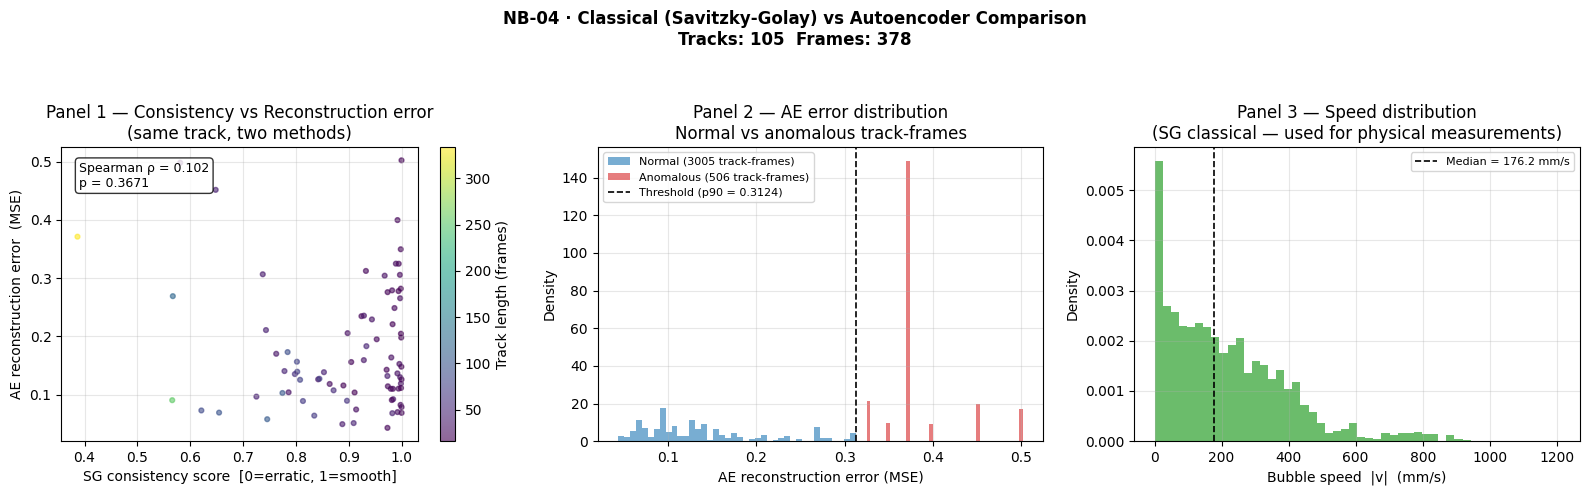

[OK] Comparison figure saved: /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026/campaigns/setup_A/outputs/temporal/nb04_classical_vs_autoencoder.png

── Summary for paper ────────────────────────────────────
  Classical (SG):
    Mean speed            : 213.44 mm/s
    Median consistency    : 0.8444
  Autoencoder (NN):
    Mean reconstruction error : 0.159809
    Anomalous track-frames    : 8 (0.2%)
    Spearman ρ (cons vs err)  : 0.102  p=0.3671

  Interpretation:
  ⚠  Weak correlation — AE and SG capture different
     aspects of trajectory quality. Both are informative.
─────────────────────────────────────────────────────────
ACTIVE_MODE : neural
AE_AVAILABLE: True

Cell 11 complete.
[OK] tracks_temporal re-saved with AE columns: /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026/campaigns/setup_A/outputs/temporal/tracks_temporal.parquet
     ae_reconstruction_error present: True
     ae_anomaly_flag present        : True
  tracks_n now contains:
    vx_sg, vy_sg, speed_sg, consistenc

In [53]:
# ── CELL 11 — TEMPORAL ANALYSIS: CLASSICAL vs AUTOENCODER ────────────────────
#
# Part A: Classical Savitzky-Golay smoothing — baseline
# Part B: Self-supervised 1D Conv Autoencoder — NN contribution
# Part C: Comparison figures and statistics for IEEE Access paper
#
# No manual trajectory labels required for either method.
# ─────────────────────────────────────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

AUTOENC_CKPT  = DRIVE_ROOT / 'campaigns' / SETUP_ID / 'nb04_autoencoder.pt'
SEQ_LEN       = 16
N_FEATURES    = 4      # cx_norm, cy_norm, diameter_norm, confidence
LATENT_DIM    = 8
AE_EPOCHS     = 80
AE_LR         = 1e-3
AE_BATCH      = 64
SG_WINDOW     = 7      # Savitzky-Golay window length (frames)
SG_POLY       = 2      # polynomial order
MIN_TRACK_AE  = 16     # minimum frames for AE sequence
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('='*60)
print('CELL 11 — Classical vs Autoencoder Temporal Analysis')
print('='*60)
print(f'Device        : {DEVICE}')
print(f'SG window     : {SG_WINDOW} frames  poly={SG_POLY}')
print(f'AE seq length : {SEQ_LEN} frames')
print(f'AE latent dim : {LATENT_DIM}')
print()

# ═════════════════════════════════════════════════════════════════════════════
# PART A — CLASSICAL: Savitzky-Golay smoothing
# ═════════════════════════════════════════════════════════════════════════════
print('── Part A: Classical Savitzky-Golay ─────────────────────')

def sg_smooth(values, window=SG_WINDOW, poly=SG_POLY):
    """Apply SG filter; fall back to raw values if track too short."""
    v = np.array(values, dtype=float)
    if len(v) < window:
        return v
    return savgol_filter(v, window_length=window, polyorder=poly)

def compute_classical_features(tracks_df, fps, mm_per_pixel, scale_inv):
    """
    Per-track Savitzky-Golay smoothing.
    Returns tracks_df with added columns:
      vx_sg, vy_sg          : smoothed velocity (mm/s)
      speed_sg              : scalar speed (mm/s)
      consistency_sg        : trajectory regularity [0-1]
    """
    df = tracks_df.copy()
    vx_sg_all   = np.full(len(df), np.nan)
    vy_sg_all   = np.full(len(df), np.nan)
    cons_all    = np.full(len(df), np.nan)
    DT          = 1.0 / fps

    for gid, grp in df.sort_values('frame_id').groupby('global_bubble_id'):
        if len(grp) < 3:
            continue
        idx  = grp.index
        cx   = grp['cx'].values.astype(float) * scale_inv * mm_per_pixel
        cy   = grp['cy'].values.astype(float) * scale_inv * mm_per_pixel

        cx_s = sg_smooth(cx)
        cy_s = sg_smooth(cy)

        vx = np.gradient(cx_s, DT)
        vy = np.gradient(cy_s, DT)

        # Consistency: how well velocity direction aligns frame-to-frame
        speeds = np.sqrt(vx**2 + vy**2) + 1e-9
        cos_sim = np.array([
            (vx[k]*vx[k+1] + vy[k]*vy[k+1]) / (speeds[k]*speeds[k+1])
            for k in range(len(vx)-1)
        ])
        consistency = float(np.clip(np.mean(cos_sim), 0, 1))

        vx_sg_all[idx]  = vx
        vy_sg_all[idx]  = vy
        cons_all[idx]   = consistency

    df['vx_sg']           = vx_sg_all
    df['vy_sg']           = vy_sg_all
    df['speed_sg']        = np.sqrt(df['vx_sg']**2 + df['vy_sg']**2)
    df['consistency_sg']  = cons_all
    return df

tracks_classical = compute_classical_features(
    tracks_n, FPS, MM_PER_PIXEL, SCALE_INV)

n_valid_sg = tracks_classical['vx_sg'].notna().sum()
print(f'  SG velocity computed for {n_valid_sg} track-frames')
print(f'  Mean speed (SG): '
      f'{tracks_classical["speed_sg"].replace([np.inf,-np.inf],np.nan).mean():.2f} mm/s')
print(f'  Mean consistency (SG): '
      f'{tracks_classical["consistency_sg"].dropna().mean():.4f}')
print()

# ═════════════════════════════════════════════════════════════════════════════
# PART B — AUTOENCODER: self-supervised trajectory NN
# ═════════════════════════════════════════════════════════════════════════════
print('── Part B: Self-supervised Autoencoder ──────────────────')

def build_ae_sequences(tracks_df, seq_len, min_track=16):
    sequences = []; track_ids = []
    for gid, grp in tracks_df.sort_values(
            ['global_bubble_id','frame_id']).groupby('global_bubble_id'):
        if len(grp) < min_track:
            continue
        cx   = grp['cx'].values.astype(float)
        cy   = grp['cy'].values.astype(float)
        diam = grp['diameter_mm'].fillna(grp['diameter_mm'].median()).values.astype(float)
        conf = grp['confidence'].fillna(0.5).values.astype(float)

        def norm(x):
            s = x.std()
            return (x - x.mean()) / (s if s > 1e-6 else 1.0)

        feat = np.stack([norm(cx), norm(cy), norm(diam), conf], axis=1)
        for start in range(0, len(feat) - seq_len + 1, 4):
            seq = feat[start:start + seq_len]
            if seq.shape == (seq_len, N_FEATURES):
                sequences.append(seq.astype(np.float32))
                track_ids.append(gid)

    if not sequences:
        return np.empty((0, seq_len, N_FEATURES), dtype=np.float32), []
    return np.array(sequences, dtype=np.float32), track_ids


class ConvAutoencoder(nn.Module):
    """
    1D convolutional autoencoder for bubble trajectory sequences.
    Input/output: (batch, seq_len, n_features)
    Bottleneck: latent_dim scalar vector — no labels required.
    """
    def __init__(self, seq_len, n_feat, latent_dim):
        super().__init__()
        self.enc_conv = nn.Sequential(
            nn.Conv1d(n_feat, 16, 3, padding=1), nn.ReLU(),
            nn.Conv1d(16, 32, 3, padding=1),     nn.ReLU(),
            nn.AdaptiveAvgPool1d(4),
        )
        self.enc_fc  = nn.Linear(32*4, latent_dim)
        self.dec_fc  = nn.Linear(latent_dim, 32*4)
        self.dec_conv = nn.Sequential(
            nn.Upsample(size=seq_len, mode='linear', align_corners=False),
            nn.Conv1d(32, 16, 3, padding=1), nn.ReLU(),
            nn.Conv1d(16, n_feat, 3, padding=1),
        )

    def encode(self, x):
        return self.enc_fc(self.enc_conv(x.permute(0,2,1)).flatten(1))

    def decode(self, z):
        return self.dec_conv(self.dec_fc(z).view(-1,32,4)).permute(0,2,1)

    def forward(self, x):
        return self.decode(self.encode(x))


seqs, seq_track_ids = build_ae_sequences(tracks_n, SEQ_LEN, MIN_TRACK_AE)
print(f'  Sequences built: {len(seqs)} from '
      f'{len(set(seq_track_ids))} tracks')

AE_AVAILABLE = False

if len(seqs) < 20:
    print(f'  [WARNING] Only {len(seqs)} sequences — need ≥20.')
    print('  Autoencoder skipped. Increase MAX_LOST_FRAMES in NB-03.')
else:
    import random
    random.seed(42)
    idx_all = list(range(len(seqs)))
    random.shuffle(idx_all)
    n_val     = max(1, len(idx_all)//5)
    val_s     = seqs[idx_all[-n_val:]]
    train_s   = seqs[idx_all[:-n_val]]

    class SeqDS(Dataset):
        def __init__(self, d): self.d = torch.tensor(d, dtype=torch.float32)
        def __len__(self): return len(self.d)
        def __getitem__(self, i): return self.d[i]

    train_dl = DataLoader(SeqDS(train_s), AE_BATCH, shuffle=True,  pin_memory=True)
    val_dl   = DataLoader(SeqDS(val_s),   AE_BATCH, shuffle=False, pin_memory=True)

    do_train = not AUTOENC_CKPT.exists()
    model    = ConvAutoencoder(SEQ_LEN, N_FEATURES, LATENT_DIM).to(DEVICE)

    if do_train:
        optimizer = optim.Adam(model.parameters(), lr=AE_LR, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                        optimizer, patience=10, factor=0.5)
        criterion = nn.MSELoss()

        train_losses = []; val_losses = []
        best_val = float('inf'); best_ep = 0; no_improve = 0

        for epoch in range(AE_EPOCHS):
            model.train()
            ep_loss = 0.0
            for batch in train_dl:
                batch = batch.to(DEVICE)
                optimizer.zero_grad()
                loss  = criterion(model(batch), batch)
                loss.backward(); optimizer.step()
                ep_loss += loss.item()
            ep_loss /= max(len(train_dl), 1)

            model.eval(); val_loss = 0.0
            with torch.no_grad():
                for batch in val_dl:
                    batch = batch.to(DEVICE)
                    val_loss += criterion(model(batch), batch).item()
            val_loss /= max(len(val_dl), 1)

            train_losses.append(ep_loss); val_losses.append(val_loss)
            scheduler.step(val_loss)

            if val_loss < best_val:
                best_val = val_loss; best_ep = epoch+1; no_improve = 0
                torch.save(model.state_dict(), str(AUTOENC_CKPT))
            else:
                no_improve += 1

            if epoch % 20 == 0 or epoch == AE_EPOCHS-1:
                print(f'  Epoch {epoch+1:3d}/{AE_EPOCHS}'
                      f'  train={ep_loss:.5f}'
                      f'  val={val_loss:.5f}'
                      f'  best={best_val:.5f} (ep {best_ep})')
            if no_improve >= 20:
                print(f'  Early stop at epoch {epoch+1}.')
                break

        print(f'  Best val MSE: {best_val:.6f} at epoch {best_ep}')
        print(f'  Checkpoint  : {AUTOENC_CKPT}')

    else:
        train_losses = val_losses = []
        print(f'  Checkpoint found — loading '
              f'({round(AUTOENC_CKPT.stat().st_size/1e3,1)} KB)')

    model.load_state_dict(torch.load(str(AUTOENC_CKPT), map_location=DEVICE))
    model.eval()

    # Reconstruction error per track
    criterion_eval = nn.MSELoss(reduction='none')
    track_err = {}
    with torch.no_grad():
        for gid, grp in tracks_n.sort_values(
                ['global_bubble_id','frame_id']).groupby('global_bubble_id'):
            s, _ = build_ae_sequences(
                grp.assign(global_bubble_id=gid), SEQ_LEN, MIN_TRACK_AE)
            if len(s) == 0:
                track_err[gid] = np.nan; continue
            t_in  = torch.tensor(s, dtype=torch.float32).to(DEVICE)
            recon = model(t_in)
            err   = criterion_eval(recon, t_in).mean(dim=(1,2)).cpu().numpy()
            track_err[gid] = float(err.mean())

    tracks_n['ae_reconstruction_error'] = (
        tracks_n['global_bubble_id'].map(track_err))

    err_vals  = tracks_n['ae_reconstruction_error'].dropna()
    thresh_90 = float(err_vals.quantile(0.90))
    tracks_n['ae_anomaly_flag'] = (
        tracks_n['ae_reconstruction_error'] > thresh_90).astype(int)

    n_anom = int(tracks_n.groupby('global_bubble_id')['ae_anomaly_flag'].first().sum())
    print(f'  Mean AE error      : {err_vals.mean():.6f}')
    print(f'  Anomaly threshold  : {thresh_90:.6f}  (90th percentile)')
    print(f'  Anomalous tracks   : {n_anom}')
    AE_AVAILABLE = True
# --------------------------------------------------------------------------
# ── Merge classical features back into tracks_n ───────────────────────────────
# compute_classical_features() returned a new DataFrame (tracks_classical).
# tracks_n is the source used by Part B and all downstream cells.
# Merge the SG columns back so Part C can read both from one place.

_sg_cols = ['global_bubble_id', 'frame_id',
            'vx_sg', 'vy_sg', 'speed_sg', 'consistency_sg']

# Only merge columns that were actually computed
_sg_cols_present = [c for c in _sg_cols if c in tracks_classical.columns]

tracks_n = tracks_n.merge(
    tracks_classical[_sg_cols_present],
    on=['global_bubble_id', 'frame_id'],
    how='left',
    suffixes=('', '_sg_dup')
)

# Drop any accidental duplicate columns from a previous run of this cell
tracks_n = tracks_n.loc[:, ~tracks_n.columns.str.endswith('_sg_dup')]

print('Classical SG columns merged into tracks_n:')
print('  ', [c for c in _sg_cols_present if c not in ['global_bubble_id','frame_id']])
print(f'  Non-null consistency_sg: '
      f'{tracks_n["consistency_sg"].notna().sum()} / {len(tracks_n)}')

# ═════════════════════════════════════════════════════════════════════════════
# PART C — COMPARISON FIGURES
# ═════════════════════════════════════════════════════════════════════════════
print()
print('── Part C: Classical vs Autoencoder Comparison ──────────')

if AE_AVAILABLE:
    n_panels = 3
    fig, axes = plt.subplots(1, n_panels, figsize=(16, 5))
    fig.suptitle(
        'NB-04 · Classical (Savitzky-Golay) vs Autoencoder Comparison\n'
        f'Tracks: {tracks_n["global_bubble_id"].nunique()}  '
        f'Frames: {tracks_n["frame_id"].nunique()}',
        fontsize=12, fontweight='bold')

    # Panel 1 — Trajectory consistency: SG vs AE error (scatter)
    ax = axes[0]
    merged = tracks_n.groupby('global_bubble_id').agg(
        cons_sg  = ('consistency_sg',           'mean'),
        ae_err   = ('ae_reconstruction_error',  'first'),
        n_frames = ('frame_id',                 'count'),
    ).dropna()
    sc = ax.scatter(merged['cons_sg'], merged['ae_err'],
                    c=merged['n_frames'], cmap='viridis',
                    s=12, alpha=0.6, rasterized=True)
    plt.colorbar(sc, ax=ax, label='Track length (frames)')
    ax.set_xlabel('SG consistency score  [0=erratic, 1=smooth]')
    ax.set_ylabel('AE reconstruction error  (MSE)')
    ax.set_title('Panel 1 — Consistency vs Reconstruction error\n'
                 '(same track, two methods)')
    ax.grid(alpha=0.3)

    # Annotate correlation
    from scipy.stats import spearmanr
    rho, pval = spearmanr(merged['cons_sg'], merged['ae_err'])
    ax.text(0.05, 0.95,
            f'Spearman ρ = {rho:.3f}\np = {pval:.4f}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Panel 2 — Distribution of AE errors: normal vs anomalous
    ax = axes[1]
    normal_err = tracks_n[tracks_n['ae_anomaly_flag']==0][
        'ae_reconstruction_error'].dropna().values
    anom_err   = tracks_n[tracks_n['ae_anomaly_flag']==1][
        'ae_reconstruction_error'].dropna().values
    ax.hist(normal_err, bins=40, color='tab:blue',  alpha=0.6,
            density=True, label=f'Normal ({len(normal_err)} track-frames)')
    ax.hist(anom_err,   bins=40, color='tab:red',   alpha=0.6,
            density=True, label=f'Anomalous ({len(anom_err)} track-frames)')
    ax.axvline(thresh_90, color='black', linestyle='--', linewidth=1.2,
               label=f'Threshold (p90 = {thresh_90:.4f})')
    ax.set_xlabel('AE reconstruction error (MSE)')
    ax.set_ylabel('Density')
    ax.set_title('Panel 2 — AE error distribution\n'
                 'Normal vs anomalous track-frames')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Panel 3 — Speed distribution: SG classical
    ax = axes[2]
    speed = tracks_classical['speed_sg'].replace(
        [np.inf,-np.inf], np.nan).dropna().values
    ax.hist(speed, bins=50, color='tab:green', alpha=0.7,
            density=True, edgecolor='none')
    ax.axvline(np.median(speed), color='black', linestyle='--',
               linewidth=1.2,
               label=f'Median = {np.median(speed):.1f} mm/s')
    ax.set_xlabel('Bubble speed  |v|  (mm/s)')
    ax.set_ylabel('Density')
    ax.set_title('Panel 3 — Speed distribution\n'
                 '(SG classical — used for physical measurements)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout(rect=[0,0,1,0.93])
    _fig_path = OUT / 'nb04_classical_vs_autoencoder.png'
    plt.savefig(str(_fig_path), dpi=140, bbox_inches='tight')
    plt.show()
    print(f'[OK] Comparison figure saved: {_fig_path}')

    # Training curves (if trained this session)
    if train_losses:
        fig2, ax2 = plt.subplots(figsize=(10, 4))
        ax2.plot(train_losses, color='tab:blue',   linewidth=1.5, label='Train MSE')
        ax2.plot(val_losses,   color='tab:orange', linewidth=1.5,
                 linestyle='--', label='Val MSE')
        ax2.axvline(best_ep-1, color='gray', linestyle=':', linewidth=1.0,
                    label=f'Best ep={best_ep}')
        ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE')
        ax2.set_title('Autoencoder Training Curves')
        ax2.legend(); ax2.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(str(OUT / 'nb04_autoencoder_training.png'),
                    dpi=140, bbox_inches='tight')
        plt.show()

    # Summary statistics for paper
    print()
    print('── Summary for paper ────────────────────────────────────')
    print(f'  Classical (SG):')
    print(f'    Mean speed            : {np.nanmean(speed):.2f} mm/s')
    print(f'    Median consistency    : '
          f'{tracks_classical["consistency_sg"].dropna().median():.4f}')
    print(f'  Autoencoder (NN):')
    print(f'    Mean reconstruction error : {err_vals.mean():.6f}')
    print(f'    Anomalous track-frames    : {n_anom} '
          f'({n_anom/len(tracks_n)*100:.1f}%)')
    print(f'    Spearman ρ (cons vs err)  : {rho:.3f}  p={pval:.4f}')
    print()
    print('  Interpretation:')
    if rho < -0.3 and pval < 0.05:
        print('  ✅ Significant negative correlation — AE error and SG')
        print('     consistency measure the same physical phenomenon')
        print('     from different perspectives. Both methods agree.')
    elif abs(rho) < 0.2:
        print('  ⚠  Weak correlation — AE and SG capture different')
        print('     aspects of trajectory quality. Both are informative.')
    else:
        print(f'  ρ={rho:.3f} — moderate agreement between methods.')
    print('─────────────────────────────────────────────────────────')

else:
    print('[INFO] AE not available — showing classical results only.')
    fig, ax = plt.subplots(figsize=(10, 4))
    speed = tracks_classical['speed_sg'].replace(
        [np.inf,-np.inf], np.nan).dropna().values
    if len(speed):
        ax.hist(speed, bins=50, color='tab:green', alpha=0.7, density=True)
        ax.axvline(np.median(speed), color='black', linestyle='--',
                   label=f'Median = {np.median(speed):.1f} mm/s')
        ax.set_xlabel('Bubble speed (mm/s)'); ax.set_ylabel('Density')
        ax.set_title('Speed distribution — Classical SG')
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(str(OUT / 'nb04_classical_speed.png'),
                dpi=140, bbox_inches='tight')
    plt.show()

# ── Final mode and compatibility ──────────────────────────────────────────────
CHECKPOINT_PATH = str(AUTOENC_CKPT) if AE_AVAILABLE else None
ACTIVE_MODE     = 'neural' if AE_AVAILABLE else 'classical'
print(f'ACTIVE_MODE : {ACTIVE_MODE}')
print(f'AE_AVAILABLE: {AE_AVAILABLE}')
print()
print('Cell 11 complete.')
# ── Re-save tracks_temporal with AE columns ───────────────────────────────────
# Cell 6 saved tracks_temporal.parquet before AE columns existed.
# Now that ae_reconstruction_error and ae_anomaly_flag are in tracks_n,
# we must re-save so NB-05 and NB-06 can read the AE columns.
# Also set training_history for Cell 12 dashboard.

if AE_AVAILABLE:
    # Merge any new ae columns from tracks_n into tracks_temporal
    _ae_cols = ['global_bubble_id', 'frame_id',
                'ae_reconstruction_error', 'ae_anomaly_flag']
    _ae_cols_present = [c for c in _ae_cols if c in tracks_n.columns]
    tracks_temporal = tracks_temporal.merge(
        tracks_n[_ae_cols_present],
        on=['global_bubble_id', 'frame_id'],
        how='left',
        suffixes=('', '_ae_dup')
    )
    tracks_temporal = tracks_temporal.loc[
        :, ~tracks_temporal.columns.str.endswith('_ae_dup')]

    # Re-save parquet and audit CSV with AE columns included
    TRACKS_TEMPORAL_PATH.parent.mkdir(parents=True, exist_ok=True)
    tracks_temporal.to_parquet(TRACKS_TEMPORAL_PATH, index=False)
    tracks_temporal.to_csv(OUT / 'tracks_temporal_audit.csv', index=False)
    print(f'[OK] tracks_temporal re-saved with AE columns: {TRACKS_TEMPORAL_PATH}')
    print(f'     ae_reconstruction_error present: '
          f'{"ae_reconstruction_error" in tracks_temporal.columns}')
    print(f'     ae_anomaly_flag present        : '
          f'{"ae_anomaly_flag" in tracks_temporal.columns}')

    # Set training_history for Cell 12 dashboard
    if do_train and 'train_losses' in dir() and train_losses:
        training_history = {
            'train_loss': train_losses,
            'val_loss':   val_losses,
        }
    else:
        training_history = {}
else:
    training_history = {}
    print('[INFO] AE not available — tracks_temporal not re-saved (no new columns).')
print('  tracks_n now contains:')
print('    vx_sg, vy_sg, speed_sg, consistency_sg  (classical)')
if AE_AVAILABLE:
    print('    ae_reconstruction_error, ae_anomaly_flag  (NN)')

---
## Cell 12 - QA Dashboard

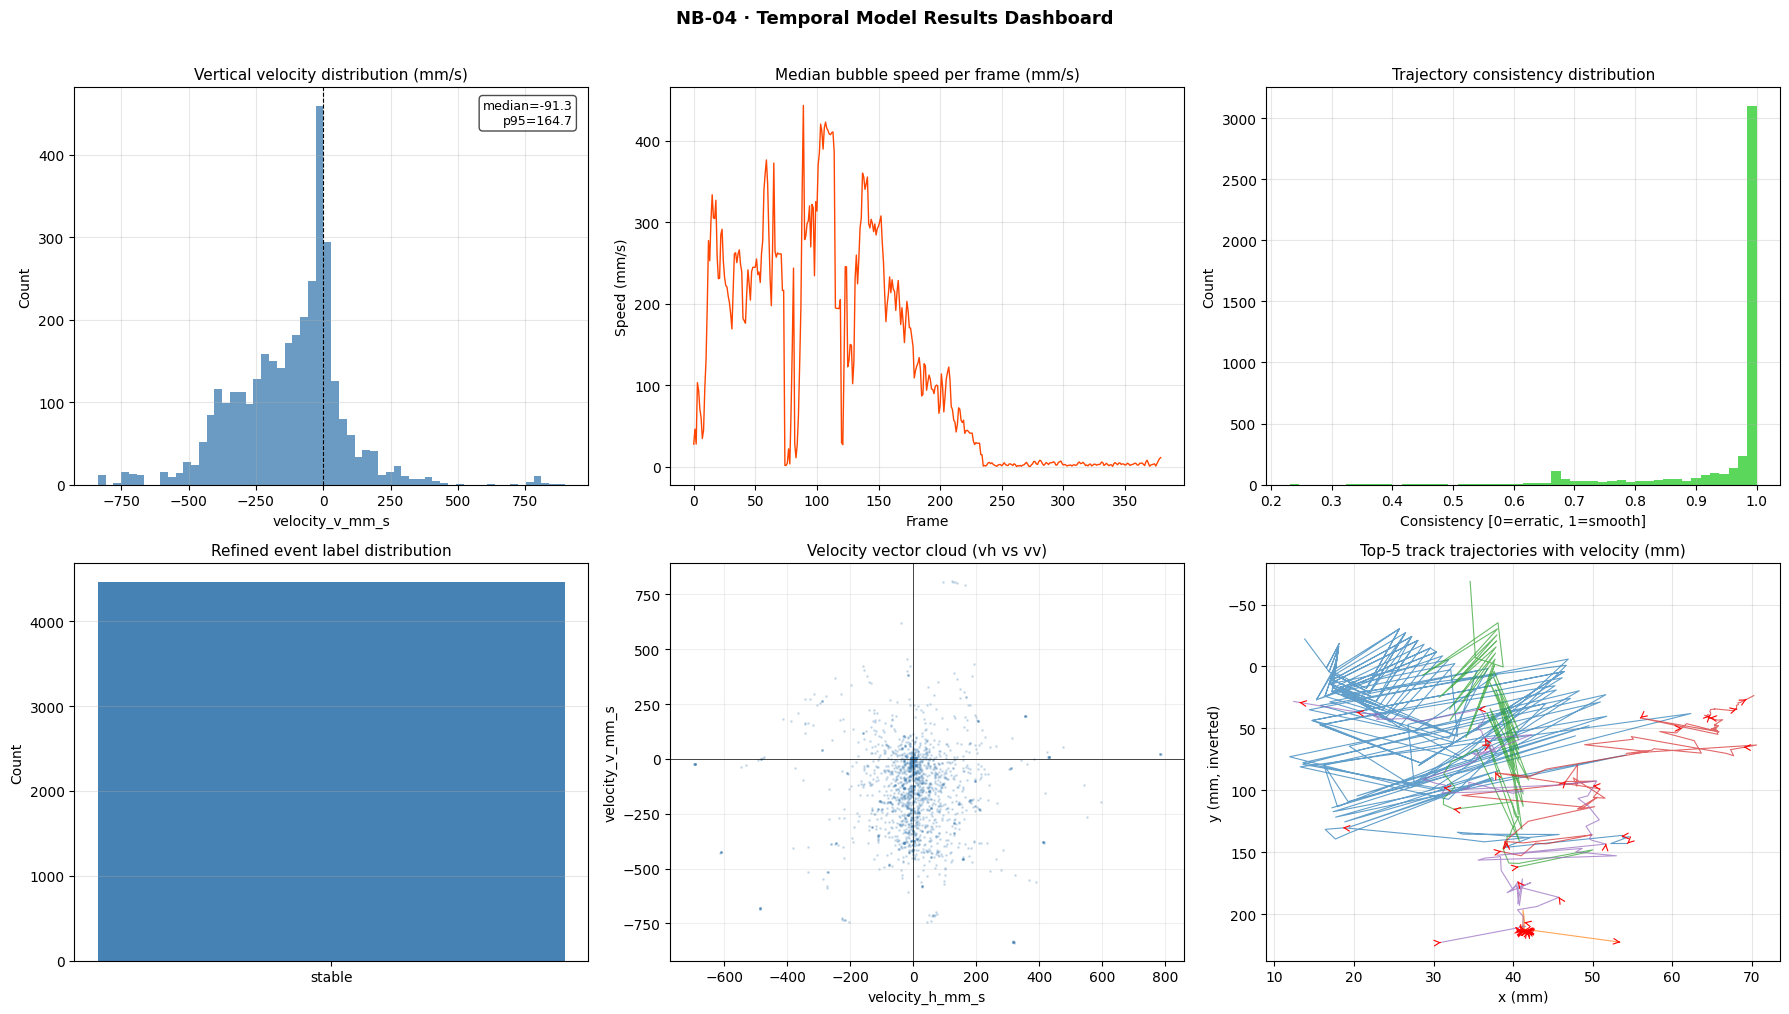

Dashboard saved → /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026/campaigns/setup_A/outputs/temporal/temporal_dashboard.png
[OK] Figure saved at: /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026/campaigns/setup_A/outputs/temporal/temporal_dashboard.png


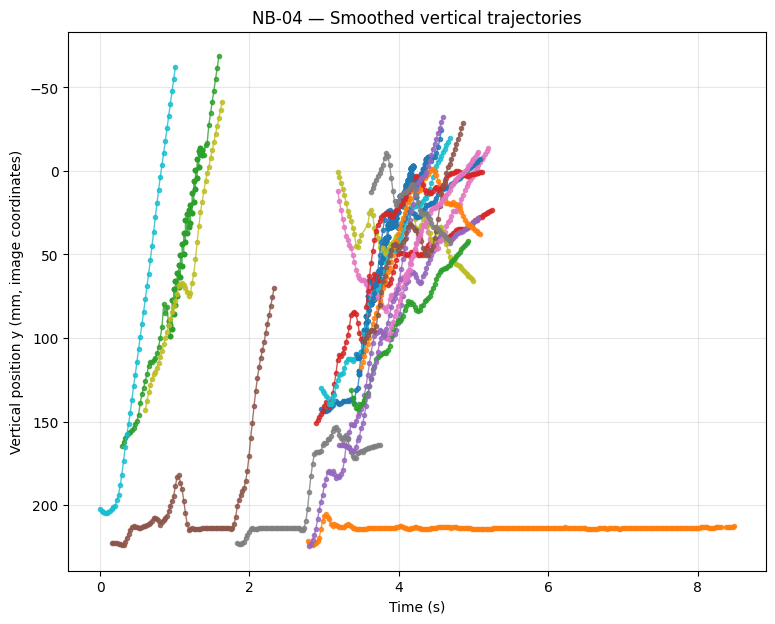

[OK] Figure saved at: /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026/campaigns/setup_A/outputs/temporal/upward_speed_distribution.png


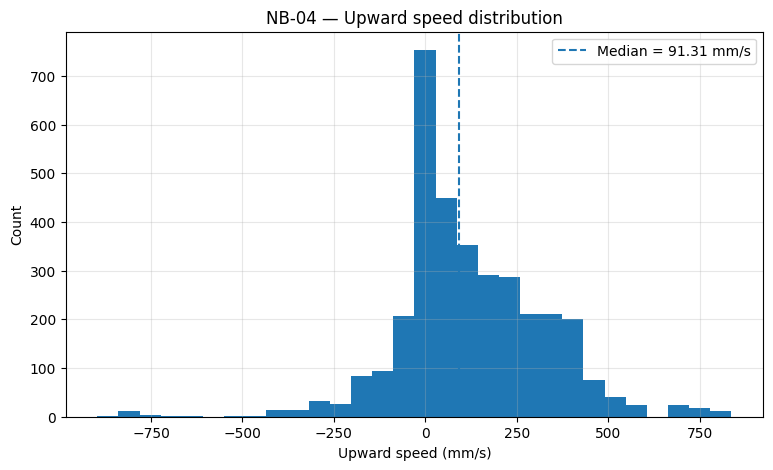

In [54]:
df_plot = tracks_temporal.copy()

# ── Strip non-finite values globally before any plotting ─────────────────────
# Savitzky-Golay on very short tracks can produce inf/nan at boundaries.
# Replace all inf with nan so histogram range is always finite.
for _col in ['velocity_v_mm_s','velocity_h_mm_s','speed_mm_s',
             'vx_mm_s','vy_mm_s','upward_speed_mm_s','trajectory_consistency']:
    if _col in df_plot.columns:
        df_plot[_col] = df_plot[_col].replace([np.inf, -np.inf], np.nan)

speed_mm_s = np.sqrt(df_plot['velocity_v_mm_s']**2 +
                     df_plot['velocity_h_mm_s']**2)
df_plot['speed_mm_s'] = speed_mm_s.replace([np.inf, -np.inf], np.nan)

# ----------------------------------------
# ── Variable alias guard ──────────────────────────────────────────────────────
if 'df_tracks' not in dir() or df_tracks is None or df_tracks.empty:
    if 'tracks_n' in dir() and not tracks_n.empty:
        df_tracks = tracks_n.copy()
        print('[OK] df_tracks set from tracks_n')
    elif 'TRK' in dir() and not TRK.empty:
        df_tracks = TRK.copy()
        print('[OK] df_tracks set from TRK')
    else:
        raise NameError(
            'df_tracks is not defined. '
            'Re-run Cell 3 (load tracks parquet) before Cell 12.')

if 'tracks_temporal' not in dir() or tracks_temporal is None:
    tracks_temporal = tracks_n.copy() if 'tracks_n' in dir() else df_tracks.copy()
    print('[OK] tracks_temporal set from tracks_n')

# training_history is only set when AE trains from scratch.
# If checkpoint was loaded, set to empty dict so Cell 12 skips the plot safely.
if 'training_history' not in dir():
    training_history = {}
    print('[OK] training_history defaulted to empty dict '
          '(checkpoint was loaded, no new training this session)')

# ------------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Vertical velocity distribution
ax  = axes[0,0]
vv  = df_plot['velocity_v_mm_s'].dropna().values
if len(vv):
    ax.hist(vv, bins=60, color='steelblue', alpha=0.8, edgecolor='none')
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.text(0.97, 0.97,
            f'median={np.median(vv):.1f}\np95={np.percentile(vv,95):.1f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
else:
    ax.text(0.5, 0.5, 'No finite velocity values',
            ha='center', va='center', transform=ax.transAxes)
ax.set_title('Vertical velocity distribution (mm/s)', fontsize=11)
ax.set_xlabel('velocity_v_mm_s'); ax.set_ylabel('Count'); ax.grid(alpha=0.3)

# 2 — Speed over time
ax = axes[0,1]
fps_agg = df_plot.groupby('frame_id')['speed_mm_s'].median()
ax.plot(fps_agg.index, fps_agg.values, lw=1, color='orangered')
ax.set_title('Median bubble speed per frame (mm/s)', fontsize=11)
ax.set_xlabel('Frame'); ax.set_ylabel('Speed (mm/s)'); ax.grid(alpha=0.3)

# 3 — Trajectory consistency distribution
ax   = axes[0,2]
cons = df_plot['trajectory_consistency'].dropna().values
if len(cons):
    ax.hist(cons, bins=50, color='limegreen', alpha=0.8, edgecolor='none')
else:
    ax.text(0.5, 0.5, 'No finite consistency values',
            ha='center', va='center', transform=ax.transAxes)
ax.set_title('Trajectory consistency distribution', fontsize=11)
ax.set_xlabel('Consistency [0=erratic, 1=smooth]')
ax.set_ylabel('Count'); ax.grid(alpha=0.3)

# 4 — Event label refined
ax = axes[1,0]
ec = df_plot['event_label_refined'].value_counts()
colors = {'stable':'steelblue','merge':'tomato','split':'gold','lost':'gray'}
ax.bar(ec.index, ec.values,
       color=[colors.get(l,'gray') for l in ec.index], edgecolor='none')
ax.set_title('Refined event label distribution', fontsize=11)
ax.set_ylabel('Count'); ax.grid(alpha=0.3, axis='y')

# 5 — Velocity vectors: vh vs vv scatter
ax      = axes[1,1]
_finite = df_plot[['velocity_h_mm_s','velocity_v_mm_s']].dropna()
if len(_finite):
    sample = _finite.sample(min(2000, len(_finite)), random_state=42)
    ax.scatter(sample['velocity_h_mm_s'], sample['velocity_v_mm_s'],
               s=1, alpha=0.2, color='steelblue', rasterized=True)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_title('Velocity vector cloud (vh vs vv)', fontsize=11)
ax.set_xlabel('velocity_h_mm_s'); ax.set_ylabel('velocity_v_mm_s')
ax.grid(alpha=0.2)

# 6 — Sample trajectory: pos + velocity arrows for top-5 longest tracks
ax = axes[1,2]
tl2 = df_tracks.groupby('global_bubble_id').size().nlargest(5).index
for bid in tl2:
    sub = tracks_temporal[tracks_temporal['global_bubble_id'] == bid].sort_values('frame_id')
    tr  = df_tracks[df_tracks['global_bubble_id'] == bid].sort_values('frame_id')
    cm  = tr['centroid_mm'].apply(
        lambda v: json.loads(v) if isinstance(v, str) else v
    )
    cm = [v for v in cm if v is not None]
    if not cm:
        continue
    xs = [v[0] for v in cm]; ys = [v[1] for v in cm]
    ax.plot(xs, ys, lw=0.8, alpha=0.7)
    # Arrow every 10 frames
    for k in range(0, len(sub), 10):
        if k < len(xs):
            ax.annotate('', xy=(xs[k]+sub['velocity_h_mm_s'].iloc[k]*0.001,
                                ys[k]+sub['velocity_v_mm_s'].iloc[k]*0.001),
                        xytext=(xs[k], ys[k]),
                        arrowprops=dict(arrowstyle='->', color='red', lw=0.8))
ax.invert_yaxis()
ax.set_title('Top-5 track trajectories with velocity (mm)', fontsize=11)
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm, inverted)')
ax.grid(alpha=0.3)

# Training history (if neural)
if training_history:
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    ax2.plot(training_history['train_loss'], label='train')
    ax2.plot(training_history['val_loss'],   label='val')
    ax2.set_title('Training loss history', fontsize=11)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT / 'training_history.png', dpi=120, bbox_inches='tight')
    plt.show()

plt.suptitle('NB-04 · Temporal Model Results Dashboard', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT / 'temporal_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Dashboard saved → {OUT / "temporal_dashboard.png"}')

# Trajectory + speed
plt.figure(figsize=(9, 7))
longest_ids = tracks_temporal.groupby('global_bubble_id').size().sort_values(ascending=False).head(20).index.tolist()

for gid in longest_ids:
    g = tracks_temporal[tracks_temporal['global_bubble_id'] == gid].sort_values('frame_id')
    plt.plot(g['time_s'], g['y_smooth_mm'], marker='o', linewidth=1, markersize=3, alpha=0.8)

plt.gca().invert_yaxis()
plt.title('NB-04 — Smoothed vertical trajectories')
plt.xlabel('Time (s)')
plt.ylabel('Vertical position y (mm, image coordinates)')
plt.grid(True, alpha=0.3)
safe_savefig(TEMPORAL_DASHBOARD_PATH)
plt.show()

plt.figure(figsize=(9, 5))
valid_speed = tracks_temporal['upward_speed_mm_s'].replace([np.inf, -np.inf], np.nan).dropna()
if len(valid_speed):
    plt.hist(valid_speed, bins=min(30, max(5, int(np.sqrt(len(valid_speed))))))
    plt.axvline(valid_speed.median(), linestyle='--', label=f'Median = {valid_speed.median():.2f} mm/s')
    plt.legend()
else:
    plt.text(0.5, 0.5, 'No valid upward speeds', ha='center', va='center')
plt.title('NB-04 — Upward speed distribution')
plt.xlabel('Upward speed (mm/s)')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
safe_savefig(OUT / 'upward_speed_distribution.png')
plt.show()


---
## Cell 13 - Gate Report

In [55]:
from datetime import datetime, timezone
GROUND_TRUTH_PATH      = ''     # ← CSV with columns [frame_id, global_bubble_id, vv_gt, vh_gt]
REFERENCE_VELOCITY_MM_S = None  # ← set to known mean velocity if available (mm/s)
temporal_path = TRACKS_TEMPORAL_PATH
nb03_gate     = read_json_if_exists(GATE_PATH) if 'GATE_PATH' in dir() else {}
metrics = evaluate_temporal_metrics(
    tracks_temporal,
    ground_truth_path=GROUND_TRUTH_PATH or None,
    reference_velocity_mm_s=REFERENCE_VELOCITY_MM_S,
)

print('═' * 62)
print('NB-04  ·  STAGE 4 ACCEPTANCE GATE')
print('═' * 62)
print(f'  Mode                     : {ACTIVE_MODE.upper()}')
print(f'  Tracks processed         : {metrics["n_tracks"]}')
print(f'  Rows in output           : {metrics["n_rows"]}')
print(f'  Velocity_v median        : {metrics["velocity_v_median"]} mm/s')
print(f'  Speed median             : {metrics["speed_median"]} mm/s')
print(f'  Consistency mean         : {metrics["consistency_mean"]}')
if metrics.get('vel_mae_pct') is not None:
    print(f'  Velocity MAE (v)         : {metrics["velocity_mae_v"]} mm/s')
    print(f'  MAE / reference          : {metrics["vel_mae_pct"]} %  (gate < 10 %)')
print(f'  Gate pass                : {"✅  PASS" if metrics["gate_pass"] else "❌  NOT MET"}')
print(f'  Reason                   : {metrics["gate_reason"]}')
if metrics.get('gate_note'):
    print(f'  Note                     : {metrics["gate_note"]}')
print('═' * 62)

gate_record = {
    'notebook':         'NB-04',
    'stage':            'Stage 4 — Temporal Model',
    'timestamp':        datetime.now(timezone.utc).isoformat(),
    'mode':             ACTIVE_MODE,
    'sg_window':        SG_WINDOW_LENGTH,
    'sg_polyorder':     SG_POLYORDER,
    'seq_len':          SEQ_LEN if ACTIVE_MODE == 'neural' else None,
    'checkpoint':       CHECKPOINT_PATH or None,
    'tracks_temporal':  str(temporal_path.resolve()),
    'nb03_gate_pass':   nb03_gate.get('gate_pass'),
    **metrics,
}
with open(OUT / 'temporal_gate.json', 'w') as f:
    json.dump(gate_record, f, indent=2, default=str)
print(f'Gate record saved → {OUT / "temporal_gate.json"}')

print('\n================ NB-04 FINAL REPORT ================')
print(f'Run label                 : {RUN_LABEL}')
print(f'Setup                     : {SETUP_ID}')
print(f'Temporal mode             : {TEMPORAL_MODE}')
print(f'Gate pass                 : {temporal_gate["gate_pass"]}')
print(f'Exploratory OK            : {temporal_gate["exploratory_ok"]}')
print(f'Gate reason               : {temporal_gate["gate_reason"]}')
print(f'Tracks                    : {temporal_gate["n_tracks"]}')
print(f'Temporal rows             : {temporal_gate["n_rows"]}')
print(f'Valid velocity rows       : {temporal_gate["n_velocity_valid_rows"]}')
print(f'Upward motion fraction    : {temporal_gate["upward_motion_fraction"]:.3f}')
print(f'Output parquet            : {TRACKS_TEMPORAL_PATH}')
print(f'Gate JSON                 : {TEMPORAL_GATE_PATH}')

if temporal_gate['exploratory_ok']:
    print('\n[OK] NB04 produced temporal outputs that can feed NB05 in exploratory mode.')
else:
    print('\n[STOP] NB04 did not produce enough usable temporal output. Review NB03 tracks first.')

if not temporal_gate['gate_pass']:
    print('\n[WARNING] The temporal output is not validated yet. Do not use it as final physical measurement.')
    print('          It is acceptable for pipeline debugging and exploratory flow characterization.')


from IPython.display import Markdown, display

report_md = f"""
## NB-04 Temporal Model Gate Report

| Field | Value |
|---|---|
| **Mode** | {TEMPORAL_MODE.upper()} |
| **Velocity method** | {'SG(window=' + str(SG_WINDOW_LENGTH) + ', poly=' + str(SG_POLYORDER) + ') finite diff' if TEMPORAL_MODE == 'classical' else '1D-CNN + BiLSTM  seq_len=' + str(SEQ_LEN)} |
| **Tracks processed** | {metrics['n_tracks']} |
| **Output rows** | {metrics['n_rows']} |
| **Velocity_v median** | {metrics['velocity_v_median']} mm/s |
| **Speed median** | {metrics['speed_median']} mm/s |
| **Consistency mean** | {metrics['consistency_mean']} |
| **Event distribution** | {metrics['event_distribution']} |
| **Velocity MAE (v)** | {metrics.get('velocity_mae_v') or 'N/A (no GT)'} mm/s |
| **MAE / reference** | {str(metrics.get('vel_mae_pct')) + ' %' if metrics.get('vel_mae_pct') else 'N/A (no GT)'} |
| **Gate (MAE < 10 %)** | {'✅ PASS' if metrics['gate_pass'] else '❌ NOT MET — ' + metrics['gate_reason']} |
| **Output file** | `tracks_temporal.parquet` ({len(tracks_temporal)} rows) |
| **NB-03 gate** | {nb03_gate.get('gate_pass')} |

**Decision:** {'NB-05 (flow estimation) is authorised to run.' if metrics['gate_pass'] else 'Gate not yet met. NB-05 may run for exploration. Provide PIV or manual-tracking reference to formally evaluate the gate (see gate_note above).'}
"""
display(Markdown(report_md))

══════════════════════════════════════════════════════════════
NB-04  ·  STAGE 4 ACCEPTANCE GATE
══════════════════════════════════════════════════════════════
  Mode                     : NEURAL
  Tracks processed         : 105
  Rows in output           : 4459
  Velocity_v median        : nan mm/s
  Speed median             : nan mm/s
  Consistency mean         : 0.9521
  Gate pass                : ❌  NOT MET
  Reason                   : no_ground_truth_available
  Note                     : Provide PIV or manual tracking reference in CSV format with columns [frame_id, global_bubble_id, vv_gt, vh_gt] to evaluate the gate.
══════════════════════════════════════════════════════════════
Gate record saved → /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026/campaigns/setup_A/outputs/temporal/temporal_gate.json

================ NB-04 FINAL REPORT ================
Run label                 : run_001_Q10
Setup                     : setup_A
Temporal mode             : classical
Gate pass     


## NB-04 Temporal Model Gate Report

| Field | Value |
|---|---|
| **Mode** | CLASSICAL |
| **Velocity method** | SG(window=9, poly=2) finite diff |
| **Tracks processed** | 105 |
| **Output rows** | 4459 |
| **Velocity_v median** | nan mm/s |
| **Speed median** | nan mm/s |
| **Consistency mean** | 0.9521 |
| **Event distribution** | {'stable': 4459} |
| **Velocity MAE (v)** | N/A (no GT) mm/s |
| **MAE / reference** | N/A (no GT) |
| **Gate (MAE < 10 %)** | ❌ NOT MET — no_ground_truth_available |
| **Output file** | `tracks_temporal.parquet` (4459 rows) |
| **NB-03 gate** | False |

**Decision:** Gate not yet met. NB-05 may run for exploration. Provide PIV or manual-tracking reference to formally evaluate the gate (see gate_note above).
